# TMS #25 — Khám phá & Phân tích (Mondelez)

Bảng ClickHouse `analytics_workspace.mdlz_tms_report_25_trip_order` — báo cáo theo **đơn hàng × chuyến**, dữ liệu **~1 tháng (tháng 5/2026)**. Mỗi dòng = 1 cặp `MasterCode × OrderCode`; đơn chưa lên chuyến có `MasterCode` rỗng.

**Luồng đọc — chạy lần lượt từ trên xuống:**

| Mức | Trả lời câu hỏi |
|---|---|
| **Setup** | Kết nối + hàm tiện ích (chạy 1 lần) |
| **L0 · Sức khỏe dữ liệu** | Toàn bộ dữ liệu đang có: độ phủ, trạng thái, cột nào dùng được |
| **L1 · Tổng quan tháng** | Đơn / chuyến / sản lượng / on-time / in-full + RAG · **bảng chi tiết đơn** để đối chiếu |
| **L2 · Biểu đồ phân tích** | Xu hướng theo ngày, cơ cấu trạng thái, on-time, top nhà xe / tỉnh / loại xe |
| **L3 · Bảng xếp hạng** | Nhà xe & tỉnh giao chi tiết |
| **L4 · Soi chi tiết** | Theo **đơn** / **chuyến** / **ngày** |
| **L5 · Truy vấn tự do** | Tự viết SQL |
| **L6 · Đối chiếu với `mv_otif`** | So đếm + Ontime + Infull cấp **đơn** TMS vs `analytics_workspace.mv_otif` — kèm danh sách đơn lệch hai chiều |

> Cột lưu `String`: số → `toFloat64OrZero`, ngày ISO `YYYY-MM-DD HH:MM:SS` → `parseDateTimeBestEffortOrNull`.
> **Định nghĩa dùng trong notebook** (chỉnh theo nghiệp vụ nếu cần): On-time = `DateToCome ≤ ETA + 30 phút` (dung sai `ONTIME_GRACE_MIN` ở cell Setup); In-full = `QuantityBBGN ≥ QuantityOrder` (**kế hoạch vs thực giao** — KHÔNG dùng `QuantityTransfer`/thực nhận ở kho); 3 cột số lượng: `QuantityOrder` (kế hoạch) · `QuantityTransfer` (lấy ở kho — chỉ tham chiếu) · `QuantityBBGN` (thực giao). Notebook chỉ dùng Order & BBGN cho metric.

## Setup — chạy 1 lần

In [171]:
import os, json
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect
from IPython.display import display, Markdown

def _find_tenant():
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if d.name == 'mondelez' and (d / '.env').exists():
            return d
        if (d / 'mondelez' / '.env').exists():
            return d / 'mondelez'
        if (d / 'projects' / 'mondelez' / '.env').exists():
            return d / 'projects' / 'mondelez'
    return here

_TENANT = _find_tenant()
load_dotenv(_TENANT / '.env')

DB, TBL = 'analytics_workspace', 'mdlz_tms_report_25_trip_order'
# Loại đơn mã không chuẩn (format "XXXXXXXX-N") — không tồn tại trong WMS Smartlog / mv_otif
SO_VALID = "position(OrderCode, '-') = 0"
T = f"(SELECT * FROM `{DB}`.`{TBL}` WHERE {SO_VALID})"
client = clickhouse_connect.get_client(
    host=os.getenv('CLICKHOUSE_HOST', ''),
    port=int(os.getenv('CLICKHOUSE_PORT', '8443')),
    username=os.getenv('CLICKHOUSE_USER', ''),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    secure=os.getenv('CLICKHOUSE_SECURE', 'true').lower() not in ('false', '0', 'no'),
)

_cols = _TENANT.parent / 'knowledge-base' / 'tms' / 'reports' / '25-trip-and-order' / '25-tms-trip-and-order.columns.json'
LABELS = {c['code']: c['label'] for c in json.loads(_cols.read_text(encoding='utf-8'))}
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 80)

NAVY, ACCENT, GREEN, AMBER, RED, BLUE, GREY = '#1E3A5F', '#2563EB', '#287819', '#E18719', '#C0392B', '#2D6EAA', '#9AA5B1'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True, 'figure.autolayout': True})

def DT(col):  return f"parseDateTimeBestEffortOrNull(nullIf({col}, ''))"
def NUM(col): return f"toFloat64OrZero({col})"

ONTIME_GRACE_MIN = 30   # dung sai on-time (phut): den dung han neu DateToCome <= ETA + grace
def ONTIME(): return f"{DT('DateToCome')} <= addMinutes({DT('ETA')}, {ONTIME_GRACE_MIN})"

KEY_COLS  = ['MasterCode', 'OrderCode', 'OrderStatus', 'MasterStatus', 'DeliveryStatus']
QTY_COLS  = ['QuantityOrder', 'QuantityTransfer', 'QuantityBBGN', 'TonOrder', 'TonBBGN', 'CBMOrder', 'CBMBBGN']
TIME_COLS = ['OrderCreatedDate', 'RequestDate', 'TenderedDate',
             'MasterETD', 'MasterATD', 'MasterETA', 'MasterATA', 'ETD', 'ETA',
             'DateFromCome', 'DateFromLeave', 'DateToCome', 'DateToLeave']
FOCUS_COLS = KEY_COLS + QTY_COLS + TIME_COLS

ANALYSIS_MASTER_STATUSES = ['Đã hoàn thành', 'Đang vận chuyển']   # trạng thái CHUYẾN (MasterStatus)
ANALYSIS_ORDER_STATUSES  = ['Đã giao hàng']                        # trạng thái ĐƠN (OrderStatus) — chỉ đơn đã hoàn thành (đã giao)
ANALYSIS_TIME_COL = 'TenderedDate'
ANALYSIS_FILTER = "MasterStatus IN {master_statuses:Array(String)} AND OrderStatus IN {order_statuses:Array(String)}"
T1 = f"(SELECT * FROM {T} WHERE {ANALYSIS_FILTER})"

def q(sql, params=None):
    return client.query_df(sql, parameters=params or {})

def q1(sql, params=None):
    merged = {'master_statuses': ANALYSIS_MASTER_STATUSES, 'order_statuses': ANALYSIS_ORDER_STATUSES}
    if params:
        merged.update(params)
    return q(sql, merged)

def fmt(n):
    try: n = float(n)
    except (TypeError, ValueError): return str(n)
    if n != n: return 'N/A'
    if abs(n) >= 1000: return f"{n:,.0f}"
    return f"{n:g}"

def rag(value, green, yellow, higher_better=True):
    if value is None or value != value: return '⚪'
    if higher_better: return '🟢' if value >= green else ('🟡' if value >= yellow else '🔴')
    return '🟢' if value <= green else ('🟡' if value <= yellow else '🔴')

def kpi(label, value, unit='', sub='', green=None, yellow=None, higher_better=True):
    flag = (rag(value, green, yellow, higher_better) + ' ') if green is not None else '   '
    tgt = f"  (target {fmt(green)}{unit})" if green is not None else ''
    print(f"{flag}{label:<30}{fmt(value)}{unit}{tgt}   {sub}")

def detail(df, all_cols=False):
    if df.empty:
        print('Khong co dong nao.'); return None
    if len(df) > 1:
        print(f'{len(df)} dong khop - hien thi dong dau.')
    row = df.iloc[0]
    show = list(df.columns) if all_cols else [c for c in FOCUS_COLS if c in df.columns]
    show = show or list(df.columns)
    return pd.DataFrame({'Truong': [LABELS.get(c, c) for c in show],
                         'Code': show, 'Gia tri': [row[c] for c in show]})

def add_total(df, label='TỔNG', sum_cols=None, wavg_cols=None, weight_col=None):
    """Thêm dòng tổng/trung bình gia quyền vào cuối DataFrame.
    - sum_cols  : list cột cộng tổng (số nguyên/thực)
    - wavg_cols : list cột trung bình gia quyền (cần weight_col)
    - weight_col: cột trọng số (thường là so_don / so_dong)
    """
    if df.empty:
        return df
    first_col = df.columns[0]
    row = {c: (None if df[c].dtype.kind in 'fiu' else '') for c in df.columns}
    row[first_col] = label
    for c in (sum_cols or []):
        if c in df.columns:
            row[c] = round(float(df[c].sum()), 2)
    if wavg_cols and weight_col and weight_col in df.columns:
        w = df[weight_col].fillna(0).astype(float)
        denom = w.sum()
        for c in wavg_cols:
            if c in df.columns:
                row[c] = round(float((df[c].fillna(0).astype(float) * w).sum() / denom), 1) if denom else None
    return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

def barh(labels, values, title, colors=NAVY, unit=''):
    fig, ax = plt.subplots(figsize=(8.5, 0.46 * len(labels) + 1.1))
    ax.barh(range(len(labels)), values, color=colors)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
    for i, v in enumerate(values):
        ax.text(v, i, ' ' + fmt(v) + unit, va='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='medium', loc='left')
    ax.grid(axis='y', alpha=0); ax.margins(x=0.12)
    plt.show()

print('Connected:', os.getenv('CLICKHOUSE_HOST'), '->', DB + '.' + TBL)
print(f'On-time grace = {ONTIME_GRACE_MIN} phut | Helpers: q(), q1(), kpi(), barh(), detail(), add_total(); expr DT()/NUM()/ONTIME()')
print(f'Base filter (SO_VALID): loại đơn mã không chuẩn (OrderCode có dấu "-") — khớp với mv_otif')
print('L1-L4 scope: MasterStatus in', ', '.join(ANALYSIS_MASTER_STATUSES),
      '| OrderStatus in', ', '.join(ANALYSIS_ORDER_STATUSES))
print('Time views use:', ANALYSIS_TIME_COL)


Connected: ghrx9lirdl.ap-southeast-1.aws.clickhouse.cloud -> analytics_workspace.mdlz_tms_report_25_trip_order
On-time grace = 30 phut | Helpers: q(), q1(), kpi(), barh(), detail(), add_total(); expr DT()/NUM()/ONTIME()
Base filter (SO_VALID): loại đơn mã không chuẩn (OrderCode có dấu "-") — khớp với mv_otif
L1-L4 scope: MasterStatus in Đã hoàn thành, Đang vận chuyển | OrderStatus in Đã giao hàng
Time views use: TenderedDate


## L0 · Sức khỏe dữ liệu — toàn bộ dữ liệu đang có
Xem trước khi phân tích: quy mô, khoảng ngày, cơ cấu trạng thái, và **cột nào đủ dữ liệu để tin**.

### L0.1 · Quy mô & cửa sổ ngày nguồn

In [172]:
display(Markdown("**Quy mô & độ phủ**"))
display(q(f"""
  SELECT count() AS so_dong,
         uniqExact(OrderCode) AS so_don,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         countIf(MasterCode = '') AS dong_chua_len_chuyen,
         min(toDate({DT('RequestDate')})) AS tu_ngay,
         max(toDate({DT('RequestDate')})) AS den_ngay
  FROM {T}
"""))
display(Markdown("**Cửa sổ ngày nguồn** (mỗi lần kéo ≤ 5 ngày)"))
display(q(f"SELECT _src_window AS cua_so_nguon, count() AS so_dong FROM {T} GROUP BY _src_window ORDER BY _src_window"))

**Quy mô & độ phủ**

,so_dong,so_don,so_chuyen,dong_chua_len_chuyen,tu_ngay,den_ngay
0,31300,24337,2289,4983,2026-05-02,2026-11-05


**Cửa sổ ngày nguồn** (mỗi lần kéo ≤ 5 ngày)

,cua_so_nguon,so_dong
0,2026-05-01..2026-05-05,6322
1,2026-05-06..2026-05-10,4920
2,2026-05-11..2026-05-15,6770
3,2026-05-16..2026-05-20,7568
4,2026-05-21..2026-05-25,4231
5,2026-05-26..2026-05-26,1489


### L0.2 · Cơ cấu trạng thái đơn / chuyến / dịch vụ

In [173]:
for col, title in [('OrderStatus', 'Trạng thái đơn'), ('DeliveryStatus', 'Trạng thái giao'),
                   ('MasterStatus', 'Trạng thái chuyến'), ('ServiceOfOrderName', 'Loại dịch vụ'),
                   ('OrderType', 'Loại đơn')]:
    print(f"\n— {title}  ({col}) —")
    display(q(f"""
      SELECT if({col} = '', '(rỗng)', {col}) AS gia_tri, count() AS so_dong,
             round(100 * count() / (SELECT count() FROM {T}), 1) AS pct
      FROM {T} GROUP BY {col} ORDER BY so_dong DESC
    """))


— Trạng thái đơn  (OrderStatus) —


,gia_tri,so_dong,pct
0,Đã giao hàng,26244,83.8
1,Đang lập kế hoạch,5009,16.0
2,Đang vận chuyển,45,0.1
3,Đơn hàng chờ,2,0.0



— Trạng thái giao  (DeliveryStatus) —


,gia_tri,so_dong,pct
0,Hoàn tất,26257,83.9
1,Chờ,5007,16.0
2,Đã lấy hàng,34,0.1
3,(rỗng),2,0.0



— Trạng thái chuyến  (MasterStatus) —


,gia_tri,so_dong,pct
0,Đã hoàn thành,26167,83.6
1,(rỗng),4983,15.9
2,Đang vận chuyển,124,0.4
3,Chưa vận chuyển,26,0.1



— Loại dịch vụ  (ServiceOfOrderName) —


,gia_tri,so_dong,pct
0,Xuất bán,31300,100.0



— Loại đơn  (OrderType) —


,gia_tri,so_dong,pct
0,Thường,31300,100.0


### L0.3 · Độ phủ cột thời gian

In [174]:
date_cols = ['OrderCreatedDate', 'RequestDate', 'TenderedDate', 'MasterETD', 'MasterATD',
             'MasterETA', 'MasterATA', 'ETD', 'ETA', 'DateFromCome', 'DateFromLeave',
             'DateToCome', 'DateToLeave', 'InvoiceDate']
sel = ", ".join(f"round(100 * countIf({c} != '') / count(), 1) AS `{c}`" for c in date_cols)
row = q(f"SELECT {sel} FROM {T}").iloc[0]
df = pd.DataFrame({'Cột': date_cols,
                   'Nhãn': [LABELS.get(c, c) for c in date_cols],
                   '% có dữ liệu': [row[c] for c in date_cols]})
display(Markdown("**Độ phủ cột thời gian** — cột < 80% nên dùng thận trọng (`InvoiceDate` ~0% → bỏ qua)"))
display(df)

**Độ phủ cột thời gian** — cột < 80% nên dùng thận trọng (`InvoiceDate` ~0% → bỏ qua)

,Cột,Nhãn,% có dữ liệu
0,OrderCreatedDate,Ngày tạo đơn,100.0
1,RequestDate,Ngày yêu cầu vận chuyển,100.0
2,TenderedDate,Thời gian gửi thầu,100.0
3,MasterETD,ETD chuyến,84.1
4,MasterATD,ATD chuyến,84.1
5,MasterETA,ETA chuyến,84.1
6,MasterATA,ATA chuyến,83.6
7,ETD,ETD đơn,100.0
8,ETA,ETA đơn,100.0
9,DateFromCome,Ngày đến điểm lấy,84.1


### L0.4 · Độ tin cột số (QTY / Tấn / Khối / KM)

In [175]:
num_cols = ['QuantityOrder', 'QuantityTransfer', 'QuantityBBGN', 'TonOrder', 'TonBBGN',
            'CBMOrder', 'CBMBBGN', 'VehicleMaxWeightStage1', 'KM']
parts = []
for c in num_cols:
    parts += [f"round(100*countIf({NUM(c)}!=0)/count(),1) AS `p_{c}`",
              f"round(min({NUM(c)}),2) AS `mn_{c}`",
              f"round(max({NUM(c)}),2) AS `mx_{c}`"]
r = q(f"SELECT {', '.join(parts)} FROM {T}").iloc[0]
display(Markdown("**Độ tin cột số** — `QuantityBBGN` (số lượng giao) sạch nhất; Tấn/Khối có giá trị âm (trả về); `VehicleMaxWeightStage1` lẫn đơn vị → **không** dùng tính VFR"))
display(pd.DataFrame([{'Cột': c, 'Nhãn': LABELS.get(c, c), '%≠0': r[f'p_{c}'],
                       'min': r[f'mn_{c}'], 'max': r[f'mx_{c}']} for c in num_cols]))

**Độ tin cột số** — `QuantityBBGN` (số lượng giao) sạch nhất; Tấn/Khối có giá trị âm (trả về); `VehicleMaxWeightStage1` lẫn đơn vị → **không** dùng tính VFR

,Cột,Nhãn,%≠0,min,max
0,QuantityOrder,Số lượng kế hoạch,100.0,0.00,6138.00
1,QuantityTransfer,Số lượng lấy,84.1,0.00,6138.00
2,QuantityBBGN,Số lượng giao,84.1,0.00,6138.00
3,TonOrder,Tấn kế hoạch,100.0,0.00,25.35
4,TonBBGN,Tấn giao,84.1,-1.12,471.90
5,CBMOrder,Khối kế hoạch,100.0,0.00,48.17
6,CBMBBGN,Khối giao,84.1,-20.98,471.33
7,VehicleMaxWeightStage1,Trọng tải,61.0,0.00,11000.00
8,KM,KM,83.3,0.00,2601.17


### L0.5 · Thống kê bất thường dữ liệu (Data Anomalies)

In [176]:

# ── L0.5.1 · Đơn hàng có nhiều hơn 1 mã chuyến (MasterCode) ──────────────────
display(Markdown("#### L0.5.1 · Đơn hàng xuất hiện trên nhiều chuyến"))

multi = q(f"""
  SELECT OrderCode,
         uniqExact(MasterCode) AS so_chuyen,
         groupUniqArray(MasterCode) AS danh_sach_chuyen,
         any(OrderStatus) AS order_status,
         any(DeliveryStatus) AS delivery_status,
         any(VendorName) AS nha_xe,
         any(StockName) AS kho_lay_hang,
         round(max({NUM('QuantityOrder')}), 0) AS kh_qty,
         round(sum({NUM('QuantityBBGN')}), 0) AS gn_qty
  FROM {T}
  WHERE MasterCode != ''
  GROUP BY OrderCode
  HAVING so_chuyen >= 2
  ORDER BY so_chuyen DESC, OrderCode
""")

summary_multi = q(f"""
  SELECT
    uniqExact(OrderCode) AS tong_don_nhieu_chuyen,
    countIf(so_chuyen = 2) AS don_2_chuyen,
    countIf(so_chuyen = 3) AS don_3_chuyen,
    countIf(so_chuyen >= 4) AS don_4_chuyen_tro_len
  FROM (
    SELECT OrderCode, uniqExact(MasterCode) AS so_chuyen
    FROM {T}
    WHERE MasterCode != ''
    GROUP BY OrderCode
    HAVING so_chuyen >= 2
  )
""").iloc[0]

tong_don = q(f"SELECT uniqExact(OrderCode) AS n FROM {T}").iloc[0]['n']
n_multi = int(summary_multi['tong_don_nhieu_chuyen'])
pct_multi = round(100 * n_multi / tong_don, 1) if tong_don else 0

print(f"Tổng số đơn trong bảng: {tong_don:,}")
print(f"Đơn xuất hiện trên ≥ 2 chuyến: {n_multi:,}  ({pct_multi}% tổng đơn)")
print(f"  Trong đó — 2 chuyến: {int(summary_multi['don_2_chuyen']):,} đơn"
      f"  |  3 chuyến: {int(summary_multi['don_3_chuyen']):,} đơn"
      f"  |  ≥4 chuyến: {int(summary_multi['don_4_chuyen_tro_len']):,} đơn")
print()

display(Markdown(f"**Danh sách {n_multi} đơn hàng trên nhiều chuyến** (sắp xếp theo số chuyến giảm dần):"))
display(multi.rename(columns={
    'OrderCode': 'Mã đơn', 'so_chuyen': 'Số chuyến',
    'danh_sach_chuyen': 'Danh sách MasterCode',
    'order_status': 'TT đơn', 'delivery_status': 'TT giao',
    'nha_xe': 'Nhà xe', 'kho_lay_hang': 'Kho lấy hàng',
    'kh_qty': 'Số lượng KH', 'gn_qty': 'Số lượng giao',
}))

# ── L0.5.2 · Đơn hàng chưa lên chuyến ────────────────────────────────────────
print()
display(Markdown("#### L0.5.2 · Đơn hàng chưa lên chuyến (MasterCode rỗng)"))
no_trip = q(f"""
  SELECT OrderStatus AS tt_don, DeliveryStatus AS tt_giao,
         count() AS so_don,
         round(sum({NUM('QuantityOrder')}), 0) AS kh_qty
  FROM {T}
  WHERE MasterCode = ''
  GROUP BY tt_don, tt_giao
  ORDER BY so_don DESC
""")
display(add_total(no_trip, sum_cols=['so_don', 'kh_qty']))

# ── L0.5.3 · Đơn hàng "Hoàn tất" nhưng thiếu thông tin thời gian thực ────────
print()
display(Markdown("#### L0.5.3 · Đơn 'Hoàn tất' thiếu DateToCome hoặc ETA (không tính được On-time)"))
missing_time = q(f"""
  SELECT
    countIf(DeliveryStatus = 'Hoàn tất') AS tong_hoan_tat,
    countIf(DeliveryStatus = 'Hoàn tất' AND ({DT('DateToCome')} IS NULL OR {DT('ETA')} IS NULL)) AS thieu_thoi_gian,
    round(100 * countIf(DeliveryStatus = 'Hoàn tất' AND ({DT('DateToCome')} IS NULL OR {DT('ETA')} IS NULL))
          / nullIf(countIf(DeliveryStatus = 'Hoàn tất'), 0), 1) AS pct_thieu
  FROM {T}
""").iloc[0]
print(f"Đơn 'Hoàn tất': {int(missing_time['tong_hoan_tat']):,}")
print(f"  Thiếu DateToCome hoặc ETA:  {int(missing_time['thieu_thoi_gian']):,}  ({missing_time['pct_thieu']}%)  → bị loại khỏi tính On-time")

# ── L0.5.4 · Đơn trả về (OrderType = 'Trả về') ───────────────────────────────
print()
display(Markdown("#### L0.5.4 · Cơ cấu đơn trả về (OrderType = 'Trả về')"))
returns = q(f"""
  SELECT DeliveryStatus AS tt_giao, count() AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_tra_ve
  FROM {T}
  WHERE OrderType = 'Trả về'
  GROUP BY tt_giao ORDER BY so_don DESC
""")
if returns.empty:
    print("Không có đơn trả về.")
else:
    display(add_total(returns, sum_cols=['so_don', 'sl_tra_ve']))


#### L0.5.1 · Đơn hàng xuất hiện trên nhiều chuyến

Tổng số đơn trong bảng: 24,337
Đơn xuất hiện trên ≥ 2 chuyến: 234  (1.0% tổng đơn)
  Trong đó — 2 chuyến: 234 đơn  |  3 chuyến: 0 đơn  |  ≥4 chuyến: 0 đơn



**Danh sách 234 đơn hàng trên nhiều chuyến** (sắp xếp theo số chuyến giảm dần):

,Mã đơn,Số chuyến,Danh sách MasterCode,TT đơn,TT giao,Nhà xe,Kho lấy hàng,Số lượng KH,Số lượng giao
0,8482485881,2,"[DI0202936, DI0202490]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,60.0,120.0
1,8482491163,2,"[DI0202937, DI0202490]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,778.0,1556.0
2,8482491164,2,"[DI0202937, DI0202490]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,447.0,798.0
3,8482493819,2,"[DI0202937, DI0202490]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,44.0,88.0
4,8482493855,2,"[DI0202937, DI0202491]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,145.0,290.0
...,...,...,...,...,...,...,...,...,...
229,8482520075,2,"[DI0207826, DI0208256]",Đang vận chuyển,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,54.0,108.0
230,8482520077,2,"[DI0207827, DI0208257]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,78.0,156.0
231,8482520080,2,"[DI0207827, DI0208257]",Đang vận chuyển,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,87.0,174.0
232,8482520081,2,"[DI0207826, DI0208257]",Đã giao hàng,Hoàn tất,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD,100.0,200.0


#### L0.5.2 · Đơn hàng chưa lên chuyến (MasterCode rỗng)

,tt_don,tt_giao,so_don,kh_qty
0,Đang lập kế hoạch,Chờ,4981.0,28101.0
1,Đơn hàng chờ,,2.0,0.0
2,TỔNG,,4983.0,28101.0


#### L0.5.3 · Đơn 'Hoàn tất' thiếu DateToCome hoặc ETA (không tính được On-time)

Đơn 'Hoàn tất': 26,257
  Thiếu DateToCome hoặc ETA:  0  (0.0%)  → bị loại khỏi tính On-time



#### L0.5.4 · Cơ cấu đơn trả về (OrderType = 'Trả về')

Không có đơn trả về.


## L1 · Tổng quan tháng
Các chỉ số chính của toàn bộ dữ liệu, kèm cờ RAG so với target nghiệp vụ (theo specs OTIF / Flash Daily).

In [177]:
m = q1(f"""
  SELECT uniqExact(OrderCode) AS so_don,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         countIf(DeliveryStatus = 'Hoàn tất') AS dong_da_giao,
         round(100 * countIf(DeliveryStatus = 'Hoàn tất') / count(), 1) AS pct_da_giao,
         round(sum({NUM('QuantityOrder')}), 0) AS sl_ke_hoach,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * sum({NUM('QuantityBBGN')}) / nullIf(sum({NUM('QuantityOrder')}), 0), 1) AS fill_rate,
         countIf(OrderType = 'Trả về') AS dong_tra_ve
  FROM {T1}
""").iloc[0]

ot = q1(f"""
  SELECT round(100 * countIf({ONTIME()})
               / nullIf(countIf({DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf({NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull
  FROM {T1} WHERE DeliveryStatus = 'Hoàn tất'
""").iloc[0]

display(Markdown(f"### {int(m['so_don']):,} đơn · {int(m['so_chuyen']):,} chuyến"))
display(Markdown(f"_Phạm vi phân tích: MasterStatus = {', '.join(ANALYSIS_MASTER_STATUSES)}_"))
kpi('Tỉ lệ đơn đã giao', m['pct_da_giao'], '%', sub=f"({int(m['dong_da_giao']):,} dòng)", green=95, yellow=85)
kpi(f'% On-time (đến ≤ ETA+{ONTIME_GRACE_MIN}′)', ot['pct_ontime'], '%', green=95, yellow=90)
kpi('% In-full (giao ≥ KH)', ot['pct_infull'], '%', green=97, yellow=92)
kpi('Fill rate (giao/kế hoạch)', m['fill_rate'], '%', green=98, yellow=92)
print()
kpi('Sản lượng kế hoạch', m['sl_ke_hoach'])
kpi('Sản lượng đã giao', m['sl_giao'])
kpi('Dòng đơn trả về', m['dong_tra_ve'])

### 20,361 đơn · 2,285 chuyến

_Phạm vi phân tích: MasterStatus = Đã hoàn thành, Đang vận chuyển_

🟢 Tỉ lệ đơn đã giao             100%  (target 95%)   (26,244 dòng)
🔴 % On-time (đến ≤ ETA+30′)     85.4%  (target 95%)   
🟢 % In-full (giao ≥ KH)         99.1%  (target 97%)   
🟢 Fill rate (giao/kế hoạch)     99.1%  (target 98%)   

   Sản lượng kế hoạch            1,486,717   
   Sản lượng đã giao             1,473,496   
   Dòng đơn trả về               0   


### L1.1 · Bảng chi tiết các đơn (để đối chiếu nhanh)
Mỗi dòng = 1 `OrderCode` (gộp các chuyến của đơn). Cờ **On-time** / **In-full** theo cùng quy ước L6 — `DateToCome ≤ ETA + grace` và `sum(BBGN) ≥ max(QuantityOrder)`. Cột `Chênh = SL giao − SL KH`, `Trễ (phút)` lấy lệch lớn nhất giữa các chuyến đã giao. Đổi `DETAIL_LIMIT` để xem nhiều/ít hơn; lọc nhanh bằng pandas trên `_orders` (vd `_orders.query("ot_flag == 'Failed'")`).

In [178]:
# Tham số bảng chi tiết — chỉnh tự do
DETAIL_LIMIT = 200    # số dòng tối đa hiển thị

_orders = q1(f"""
  SELECT OrderCode AS ma_don,
         toDate(min({DT('TenderedDate')})) AS ngay_yc,
         any(OrderStatus) AS tt_don,
         any(VendorName) AS nha_xe,
         any(StockName) AS kho_lay,
         any(OPSLocationToProvince) AS tinh_giao,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         arrayStringConcat(groupUniqArrayIf(MasterCode, MasterCode != ''), ', ') AS ma_chuyen,
         countIf(DeliveryStatus = 'Hoàn tất') AS dong_da_giao,
         countIf(DeliveryStatus = 'Hoàn tất'
                 AND {DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL) AS dong_eval_ot,
         countIf(DeliveryStatus = 'Hoàn tất'
                 AND {DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL
                 AND NOT ({ONTIME()})) AS dong_tre,
         round(max({NUM('QuantityOrder')}), 0) AS kh,
         round(sum({NUM('QuantityBBGN')}), 0) AS giao,
         max(dateDiff('minute', {DT('ETA')}, {DT('DateToCome')})) AS tre_phut_max
  FROM {T1}
  GROUP BY ma_don
  ORDER BY ngay_yc DESC, ma_don
  LIMIT {DETAIL_LIMIT}
""")

def _ot_flag(da_giao, eval_ot, tre):
    if da_giao == 0:   return 'Chưa giao'
    if eval_ot == 0:   return 'Thiếu thời gian'
    if tre > 0:        return '🔴 Failed'
    return '🟢 Ontime'

def _if_flag(da_giao, kh, gn):
    if da_giao == 0:   return 'Chưa giao'
    if kh == 0:        return 'KH = 0'
    if gn >= kh:       return '🟢 Infull'
    return '🔴 Failed'

_orders['ot_flag'] = [_ot_flag(d, e, t) for d, e, t in
                      zip(_orders['dong_da_giao'], _orders['dong_eval_ot'], _orders['dong_tre'])]
_orders['if_flag'] = [_if_flag(d, k, g) for d, k, g in
                      zip(_orders['dong_da_giao'], _orders['kh'], _orders['giao'])]
_orders['chenh'] = (_orders['giao'] - _orders['kh']).round(0)

_show = _orders[['ma_don', 'ngay_yc', 'tt_don', 'nha_xe', 'kho_lay', 'tinh_giao',
                 'so_chuyen', 'ma_chuyen', 'kh', 'giao', 'chenh',
                 'ot_flag', 'if_flag', 'tre_phut_max']].rename(columns={
    'ma_don': 'Mã đơn', 'ngay_yc': 'Ngày YC', 'tt_don': 'TT đơn',
    'nha_xe': 'Nhà xe', 'kho_lay': 'Kho lấy', 'tinh_giao': 'Tỉnh giao',
    'so_chuyen': 'Số chuyến', 'ma_chuyen': 'Mã chuyến',
    'kh': 'SL KH', 'giao': 'SL giao', 'chenh': 'Chênh',
    'ot_flag': 'On-time', 'if_flag': 'In-full', 'tre_phut_max': 'Trễ (phút)',
})

print(f"Hiển thị {len(_show)} / tổng {int(m['so_don']):,} đơn (đổi DETAIL_LIMIT để xem thêm).")
print("Lọc nhanh: _orders.query(\"ot_flag == '🔴 Failed'\")  |  _orders.query(\"if_flag == '🔴 Failed'\")  |  _orders.query(\"ot_flag == 'Chưa giao'\")")
display(_show)


Hiển thị 200 / tổng 20,361 đơn (đổi DETAIL_LIMIT để xem thêm).
Lọc nhanh: _orders.query("ot_flag == '🔴 Failed'")  |  _orders.query("if_flag == '🔴 Failed'")  |  _orders.query("ot_flag == 'Chưa giao'")


,Mã đơn,Ngày YC,TT đơn,Nhà xe,Kho lấy,Tỉnh giao,Số chuyến,Mã chuyến,SL KH,SL giao,Chênh,On-time,In-full,Trễ (phút)
0,8482518699,2026-05-28,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0208207,45.0,90.0,45.0,🟢 Ontime,🟢 Infull,-450
1,8482518710,2026-05-28,Đã giao hàng,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,Kho trong - BKD,Hà Nội,1,DI0208118,188.0,376.0,188.0,🟢 Ontime,🟢 Infull,-309
2,8482518784,2026-05-28,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0208207,72.0,144.0,72.0,🟢 Ontime,🟢 Infull,-450
3,8482518785,2026-05-28,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0208207,60.0,120.0,60.0,🟢 Ontime,🟢 Infull,-450
4,8482519934,2026-05-28,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0208207,1.0,1.0,0.0,🟢 Ontime,🟢 Infull,-450
5,8482517234,2026-05-27,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0207955,23.0,23.0,0.0,🟢 Ontime,🟢 Infull,-501
6,8482517235,2026-05-27,Đã giao hàng,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Hà Nội,1,DI0207994,19.0,19.0,0.0,🟢 Ontime,🟢 Infull,-614
7,8482517238,2026-05-27,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0207958,24.0,24.0,0.0,🟢 Ontime,🟢 Infull,-352
8,8482517240,2026-05-27,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0207950,95.0,95.0,0.0,🟢 Ontime,🟢 Infull,-284
9,8482518306,2026-05-27,Đã giao hàng,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Hà Nội,1,DI0207957,20.0,20.0,0.0,🟢 Ontime,🟢 Infull,-509


## L2 · Biểu đồ phân tích
Bảy góc nhìn: nhịp sản lượng theo ngày, cơ cấu trạng thái, on-time theo tuần, và xếp hạng nhà xe / **kho** / tỉnh giao / loại xe.

### L2.1 · Sản lượng theo ngày — kế hoạch vs đã giao

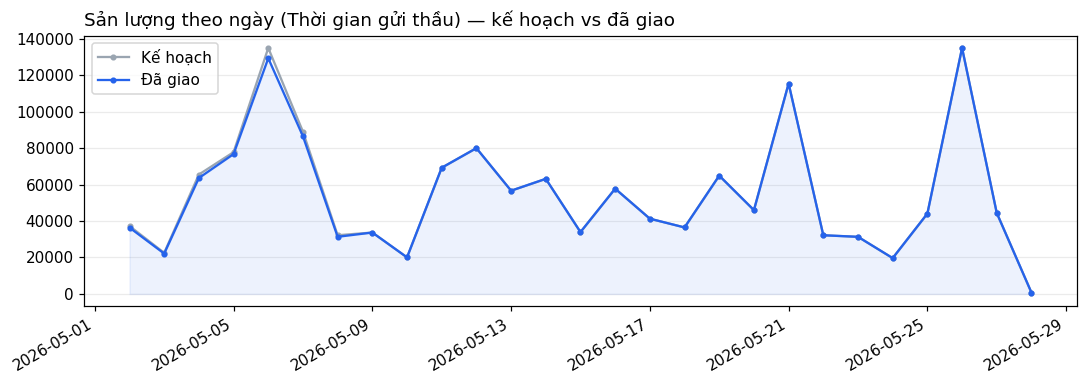

In [179]:
TREND_FROM, TREND_TO, TREND_DATE = '2026-05-01', '2026-05-31', ANALYSIS_TIME_COL   # đổi để xem khoảng khác
t = q1(f"""
  SELECT toDate({DT(TREND_DATE)}) AS ngay,
         round(sum({NUM('QuantityOrder')}), 0) AS ke_hoach,
         round(sum({NUM('QuantityBBGN')}), 0) AS da_giao
  FROM {T1}
  WHERE toDate({DT(TREND_DATE)}) BETWEEN {{a:Date}} AND {{b:Date}}
  GROUP BY ngay ORDER BY ngay
""", {"a": TREND_FROM, "b": TREND_TO})

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t['ngay'], t['ke_hoach'], marker='o', ms=3, color=GREY, label='Kế hoạch')
ax.plot(t['ngay'], t['da_giao'], marker='o', ms=3, color=ACCENT, label='Đã giao')
ax.fill_between(t['ngay'], t['da_giao'], color=ACCENT, alpha=0.08)
ax.set_title(f'Sản lượng theo ngày ({LABELS.get(TREND_DATE, TREND_DATE)}) — kế hoạch vs đã giao',
             loc='left', fontweight='medium')
ax.legend(); ax.grid(axis='x', alpha=0); fig.autofmt_xdate(); plt.show()

### L2.2 · KPI theo ngày (bảng RAG)

In [180]:
DAILY_FROM, DAILY_TO, DAILY_DATE = TREND_FROM, TREND_TO, ANALYSIS_TIME_COL   # đổi DAILY_DATE nếu muốn đọc theo mốc thời gian khác

d = q1(f"""
  SELECT toDate({DT(DAILY_DATE)}) AS ngay,
         uniqExact(OrderCode) AS tong_don,
         uniqExactIf(MasterCode, MasterCode != '') AS tong_chuyen,
         round(100 * countIf(DeliveryStatus = 'Hoàn tất') / count(), 1) AS pct_da_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull,
         round(100 * sum({NUM('QuantityBBGN')}) / nullIf(sum({NUM('QuantityOrder')}), 0), 1) AS fill_rate,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao
  FROM {T1}
  WHERE toDate({DT(DAILY_DATE)}) BETWEEN {{a:Date}} AND {{b:Date}}
  GROUP BY ngay ORDER BY ngay
""", {"a": DAILY_FROM, "b": DAILY_TO})

bang = pd.DataFrame({
    'Ngày':          d['ngay'].astype(str),
    'Tổng đơn':      d['tong_don'].map(fmt),
    'Tổng chuyến':   d['tong_chuyen'].map(fmt),
    '% Đã giao':     [f"{rag(v, 95, 85)} {fmt(v)}" for v in d['pct_da_giao']],
    '% On-time':     [f"{rag(v, 95, 90)} {fmt(v)}" for v in d['pct_ontime']],
    '% In-full':     [f"{rag(v, 97, 92)} {fmt(v)}" for v in d['pct_infull']],
    'Fill rate %':   d['fill_rate'].map(fmt),
    'Số lượng giao': d['sl_giao'].map(fmt),
})
# Dòng TỔNG — count columns: sum; % columns: trung bình đơn giản theo ngày
_t = pd.DataFrame([{
    'Ngày':          'TỔNG / avg',
    'Tổng đơn':      fmt(d['tong_don'].sum()),
    'Tổng chuyến':   fmt(d['tong_chuyen'].sum()),
    '% Đã giao':     f"  {d['pct_da_giao'].mean():.1f} avg",
    '% On-time':     f"  {d['pct_ontime'].mean():.1f} avg",
    '% In-full':     f"  {d['pct_infull'].mean():.1f} avg",
    'Fill rate %':   f"{d['fill_rate'].mean():.1f} avg",
    'Số lượng giao': fmt(d['sl_giao'].sum()),
}])
bang = pd.concat([bang, _t], ignore_index=True)
display(Markdown(f"### KPI theo ngày · {LABELS.get(DAILY_DATE, DAILY_DATE)} · {DAILY_FROM} → {DAILY_TO}"))
display(bang)
print(f"On-time = đến ≤ ETA đơn + {ONTIME_GRACE_MIN}′ · In-full = giao ≥ KH · % tính trên dòng đã 'Hoàn tất' · Tổng đơn/chuyến cộng theo ngày (không loại trùng liên ngày)")

### KPI theo ngày · Thời gian gửi thầu · 2026-05-01 → 2026-05-31

,Ngày,Tổng đơn,Tổng chuyến,% Đã giao,% On-time,% In-full,Fill rate %,Số lượng giao
0,2026-05-02,274,71,🟢 100,🔴 87.4,🔴 91.2,97.7,"36,420"
1,2026-05-03,"1,016",49,🟢 100,🟡 92.1,🟢 98.9,98.2,"22,150"
2,2026-05-04,745,128,🟢 100,🔴 58.6,🟡 96.7,97.1,"63,683"
3,2026-05-05,"2,367",136,🟢 100,🟡 93.5,🟢 97.5,98.6,"76,821"
4,2026-05-06,852,104,🟢 100,🟡 91.5,🟡 95.3,95.8,"129,474"
5,2026-05-07,646,124,🟢 100,🔴 77.9,🟡 94.4,97.2,"86,593"
6,2026-05-08,221,66,🟢 100,🔴 78.3,🟡 96.8,97.4,"31,372"
7,2026-05-09,353,62,🟢 100,🔴 86.8,🟢 100,100,"33,723"
8,2026-05-10,697,47,🟢 100,🔴 86.2,🟢 100,100,"20,066"
9,2026-05-11,"1,009",85,🟢 100,🔴 86.2,🟢 100,100,"69,324"


On-time = đến ≤ ETA đơn + 30′ · In-full = giao ≥ KH · % tính trên dòng đã 'Hoàn tất' · Tổng đơn/chuyến cộng theo ngày (không loại trùng liên ngày)


### L2.3 · Cơ cấu trạng thái đơn

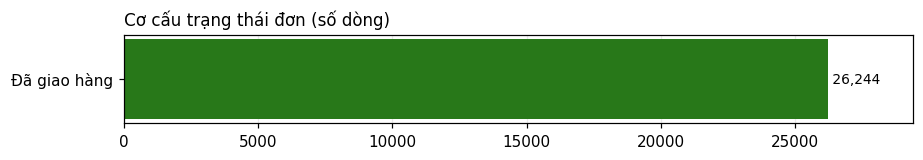

In [181]:
s = q1(f"SELECT OrderStatus AS tt, count() AS n FROM {T1} GROUP BY tt ORDER BY n DESC")
cmap = {'Đã giao hàng': GREEN, 'Đang vận chuyển': BLUE, 'Đang lập kế hoạch': AMBER, 'Đơn hàng chờ': GREY}
barh([(x or '(rỗng)') for x in s['tt']], list(s['n']),
     'Cơ cấu trạng thái đơn (số dòng)', colors=[cmap.get(x, NAVY) for x in s['tt']])

### L2.4 · % On-time theo tuần

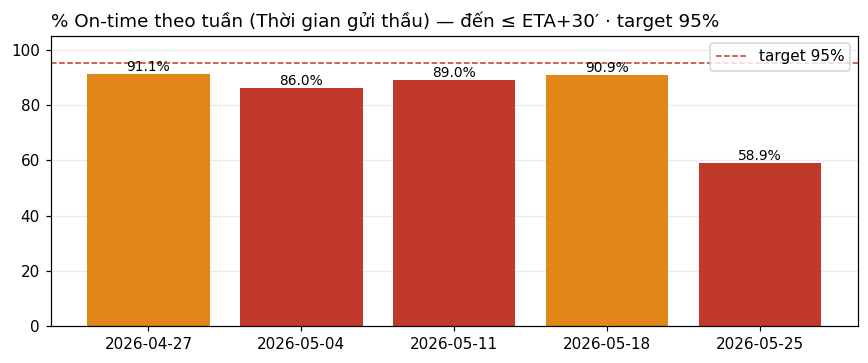

In [182]:
w = q1(f"""
  SELECT toMonday(toDate({DT(ANALYSIS_TIME_COL)})) AS tuan,
         round(100 * countIf({ONTIME()}) / nullIf(count(), 0), 1) AS pct_ontime,
         count() AS n
  FROM {T1}
  WHERE DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL
    AND toDate({DT(ANALYSIS_TIME_COL)}) BETWEEN '2026-05-01' AND '2026-05-31'
  GROUP BY tuan ORDER BY tuan
""")
fig, ax = plt.subplots(figsize=(8, 3.4))
colors = [GREEN if v >= 95 else (AMBER if v >= 90 else RED) for v in w['pct_ontime']]
ax.bar(w['tuan'].astype(str), w['pct_ontime'], color=colors)
ax.axhline(95, ls='--', color=RED, lw=1, label='target 95%')
for i, v in enumerate(w['pct_ontime']):
    ax.text(i, v, f"{v}%", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 105)
ax.set_title(f'% On-time theo tuần ({LABELS.get(ANALYSIS_TIME_COL, ANALYSIS_TIME_COL)}) — đến ≤ ETA+{ONTIME_GRACE_MIN}′ · target 95%', loc='left', fontweight='medium')
ax.legend(); ax.grid(axis='x', alpha=0); plt.show()

### L2.5 · Top 10 nhà xe theo sản lượng

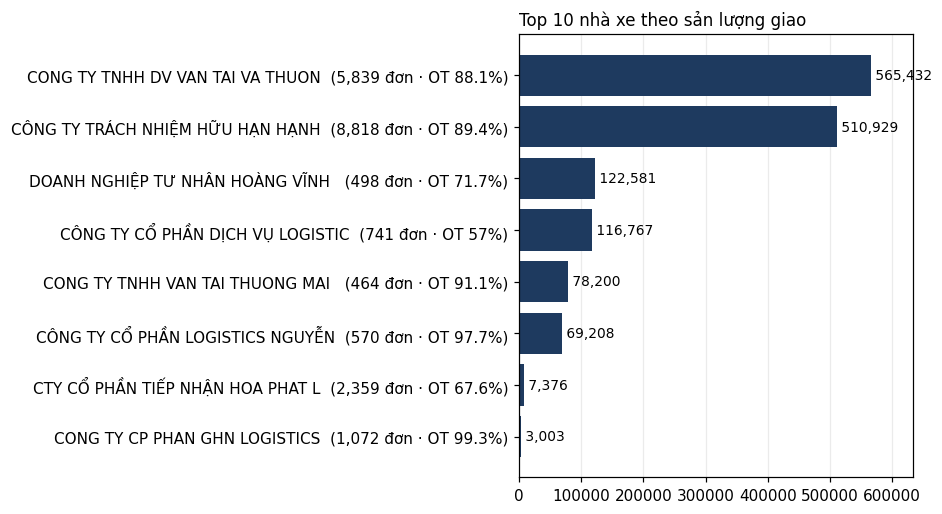

In [183]:
v = q1(f"""
  SELECT VendorName AS nha_xe,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         uniqExact(OrderCode) AS so_don,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T1} WHERE VendorName != '' GROUP BY nha_xe ORDER BY sl_giao DESC LIMIT 10
""")
labels = [f"{n[:32]}  ({fmt(d)} đơn · OT {fmt(o)}%)" for n, d, o in zip(v['nha_xe'], v['so_don'], v['pct_ontime'])]
barh(labels, list(v['sl_giao']), 'Top 10 nhà xe theo sản lượng giao', colors=NAVY)

### L2.6 · On-time theo kho điểm lấy

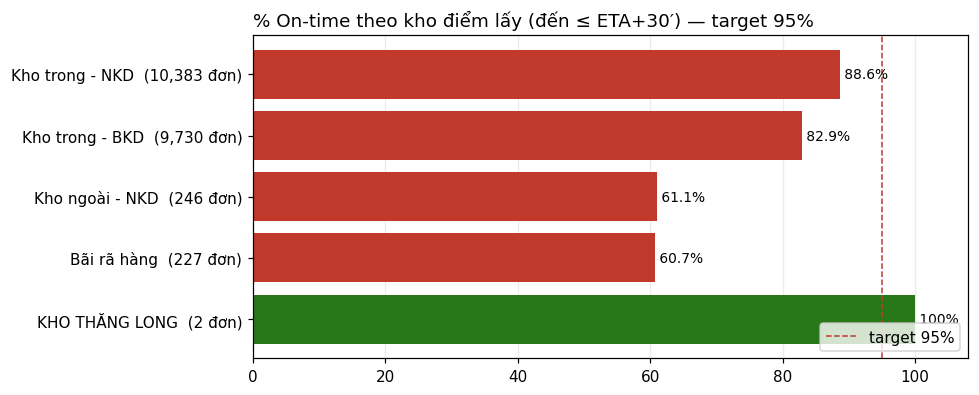

In [184]:
wh = q1(f"""
  SELECT if(StockName = '', '(rỗng)', StockName) AS kho,
         uniqExact(OrderCode) AS so_don,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T1} WHERE StockName != '' GROUP BY kho ORDER BY so_don DESC LIMIT 8
""")
fig, ax = plt.subplots(figsize=(9, 0.5 * len(wh) + 1.2))
colors = [GREEN if v >= 95 else (AMBER if v >= 90 else RED) for v in wh['pct_ontime']]
ax.barh(range(len(wh)), wh['pct_ontime'], color=colors)
ax.set_yticks(range(len(wh)))
ax.set_yticklabels([f"{k}  ({fmt(d)} đơn)" for k, d in zip(wh['kho'], wh['so_don'])])
ax.invert_yaxis()
ax.axvline(95, ls='--', color=RED, lw=1, label='target 95%')
for i, v in enumerate(wh['pct_ontime']):
    ax.text(v, i, f" {fmt(v)}%", va='center', fontsize=9)
ax.set_xlim(0, 108)
ax.set_title(f'% On-time theo kho điểm lấy (đến ≤ ETA+{ONTIME_GRACE_MIN}′) — target 95%', loc='left', fontweight='medium')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0); plt.show()

### L2.7 · Top tỉnh điểm giao theo sản lượng

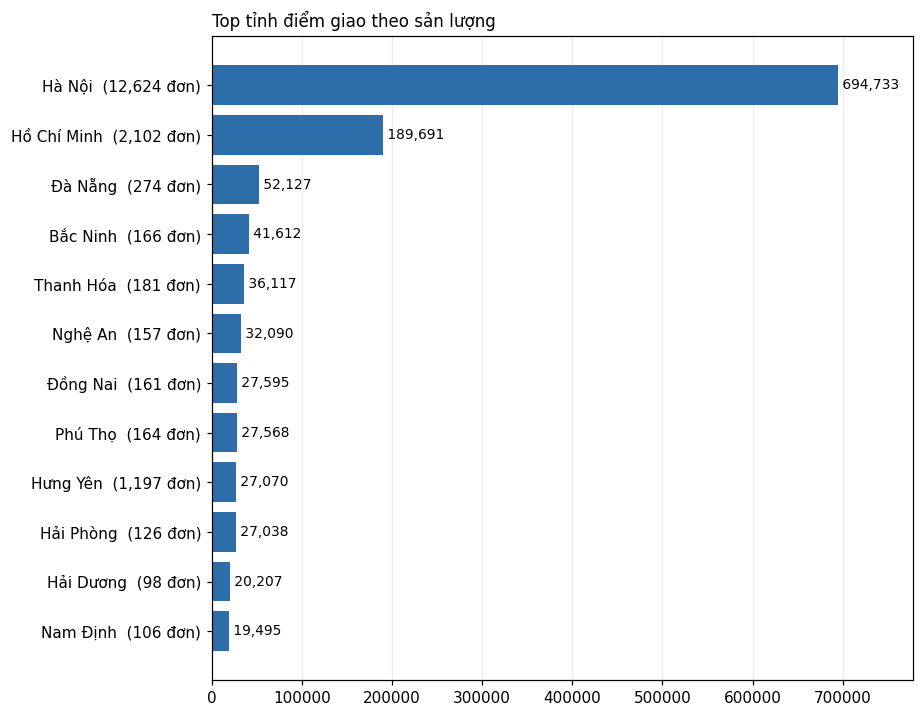

In [185]:
p = q1(f"""
  SELECT OPSLocationToProvince AS tinh, round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         uniqExact(OrderCode) AS so_don
  FROM {T1} WHERE OPSLocationToProvince != '' GROUP BY tinh ORDER BY sl_giao DESC LIMIT 12
""")
barh([f"{t}  ({fmt(d)} đơn)" for t, d in zip(p['tinh'], p['so_don'])], list(p['sl_giao']),
     'Top tỉnh điểm giao theo sản lượng', colors=BLUE)

### L2.8 · Cơ cấu loại xe theo sản lượng

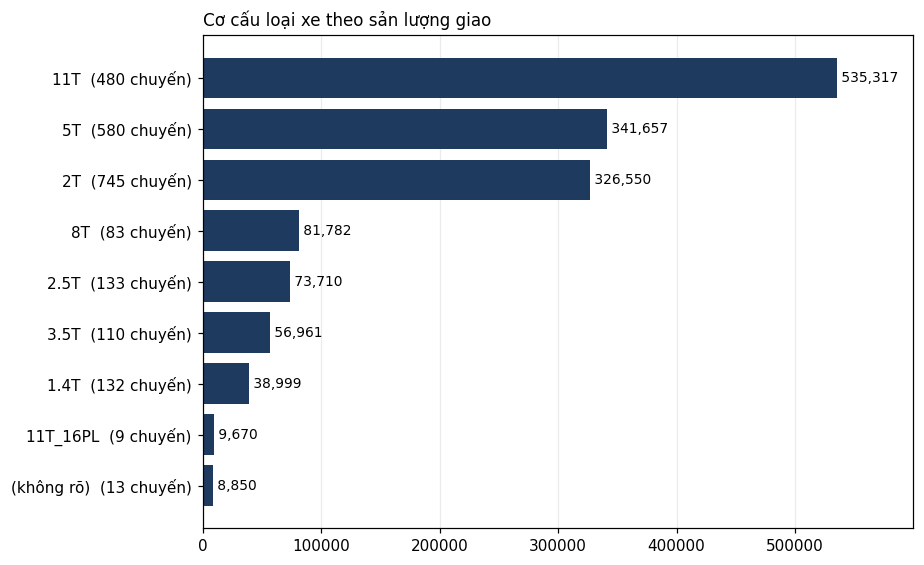

In [186]:
veh = q1(f"""
  SELECT if(GroupOfVehicleName = '', '(không rõ)', GroupOfVehicleName) AS loai_xe,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao
  FROM {T1} GROUP BY loai_xe ORDER BY sl_giao DESC LIMIT 12
""")
barh([f"{x}  ({fmt(c)} chuyến)" for x, c in zip(veh['loai_xe'], veh['so_chuyen'])], list(veh['sl_giao']),
     'Cơ cấu loại xe theo sản lượng giao', colors=NAVY)

## L3 · Bảng xếp hạng
Số liệu chi tiết để lọc/sort thêm — nhà xe (≥ 50 đơn), **kho điểm lấy**, và tỉnh điểm giao.

### L3.1 · Hiệu suất nhà xe (≥ 50 đơn)

In [187]:
display(Markdown("**Hiệu suất nhà xe** (≥ 50 đơn)"))
_v = q1(f"""
  SELECT VendorName AS nha_xe,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull
  FROM {T1} WHERE VendorName != '' GROUP BY nha_xe HAVING so_don >= 50 ORDER BY sl_giao DESC LIMIT 20
""")
display(add_total(_v, sum_cols=['so_chuyen', 'so_don', 'sl_giao'],
                  wavg_cols=['pct_ontime', 'pct_infull'], weight_col='so_don'))

**Hiệu suất nhà xe** (≥ 50 đơn)

,nha_xe,so_chuyen,so_don,sl_giao,pct_ontime,pct_infull
0,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,980.0,5839.0,565432.0,88.1,98.2
1,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,837.0,8818.0,510929.0,89.4,99.4
2,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,90.0,498.0,122581.0,71.7,97.4
3,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,123.0,741.0,116767.0,57.0,98.5
4,CONG TY TNHH VAN TAI THUONG MAI DICH VỤ THANH AN,119.0,464.0,78200.0,91.1,97.8
5,CÔNG TY CỔ PHẦN LOGISTICS NGUYỄN PHÁT,114.0,570.0,69208.0,97.7,99.6
6,CTY CỔ PHẦN TIẾP NHẬN HOA PHAT LOGISTICS,15.0,2359.0,7376.0,67.6,100.0
7,CONG TY CP PHAN GHN LOGISTICS,7.0,1072.0,3003.0,99.3,100.0
8,TỔNG,2285.0,20361.0,1473496.0,85.7,99.0


### L3.2 · Theo kho điểm lấy

In [188]:
display(Markdown("**Theo kho điểm lấy**"))
_w = q1(f"""
  SELECT StockName AS kho, StockCode AS ma_kho,
         uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull
  FROM {T1} WHERE StockName != '' GROUP BY kho, ma_kho ORDER BY so_don DESC LIMIT 15
""")
display(add_total(_w, sum_cols=['so_don', 'sl_giao'],
                  wavg_cols=['pct_ontime', 'pct_infull'], weight_col='so_don'))

**Theo kho điểm lấy**

,kho,ma_kho,so_don,sl_giao,pct_ontime,pct_infull
0,Kho trong - NKD,NKD,10383.0,474411.0,88.6,99.6
1,Kho trong - BKD,BKD,9730.0,802569.0,82.9,98.7
2,Kho ngoài - NKD,VN831,246.0,153551.0,61.1,92.4
3,Bãi rã hàng,99999,227.0,41559.0,60.7,98.3
4,KHO THĂNG LONG,VN832,2.0,1406.0,100.0,100.0
5,TỔNG,,20588.0,1473496.0,85.3,99.1


### L3.3 · Theo tỉnh điểm giao

In [189]:
display(Markdown("**Theo tỉnh điểm giao**"))
_p = q1(f"""
  SELECT OPSLocationToProvince AS tinh, uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T1} WHERE OPSLocationToProvince != '' GROUP BY tinh ORDER BY so_don DESC LIMIT 20
""")
display(add_total(_p, sum_cols=['so_don', 'sl_giao'],
                  wavg_cols=['pct_ontime'], weight_col='so_don'))

**Theo tỉnh điểm giao**

,tinh,so_don,sl_giao,pct_ontime
0,Hà Nội,12624.0,694733.0,92.4
1,Hồ Chí Minh,2102.0,189691.0,64.5
2,Hưng Yên,1197.0,27070.0,91.0
3,Bình Dương,742.0,16942.0,81.1
4,Đà Nẵng,274.0,52127.0,60.6
5,Cần Thơ,221.0,7937.0,98.1
6,Thanh Hóa,181.0,36117.0,61.6
7,Bắc Ninh,166.0,41612.0,76.6
8,Phú Thọ,164.0,27568.0,59.6
9,Đồng Nai,161.0,27595.0,95.5


### L3.4 · Đơn không OTIF — danh sách (không On-time / không In-full)

Quy ước:
- **On-time**: `DateToCome <= ETA + 30 phút` (grace mặc định trong setup — `ONTIME()`)
- **In-full**: `QuantityBBGN >= QuantityOrder` (số lượng thực giao ≥ kế hoạch — KHÔNG so với `QuantityTransfer`/thực nhận ở kho)
- **Scope**: đơn đã giao (`DeliveryStatus = 'Hoàn tất'`). Đơn thiếu `ETA`/`DateToCome` không đánh giá on-time; đơn `QuantityOrder = 0` không đánh giá in-full.

Mỗi dòng = 1 cặp `Order × MasterCode`. Một đơn vào nhiều chuyến → có thể xuất hiện nhiều dòng (mỗi chuyến đánh giá riêng).


In [190]:
# Tham số — đổi tự do
FAIL_LIMIT = 100   # số dòng tối đa hiển thị mỗi bảng

# Biểu thức đánh giá
INFULL_EXPR    = f"{NUM('QuantityBBGN')} >= {NUM('QuantityOrder')}"            # đủ hoặc vượt
NOT_INFULL     = f"{NUM('QuantityOrder')} > 0 AND {NUM('QuantityBBGN')} < {NUM('QuantityOrder')}"
ONTIME_EVAL    = f"{DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL"  # đủ dữ liệu chấm on-time
NOT_ONTIME     = f"{ONTIME_EVAL} AND NOT ({ONTIME()})"

# ── Tóm tắt OTIF (dòng đã giao) ───────────────────────────────────────────
display(Markdown('**Tóm tắt OTIF — đơn đã giao (`DeliveryStatus = Hoàn tất`)**'))
_otif = q1(f"""
  SELECT
    countIf(DeliveryStatus = 'Hoàn tất') AS so_dong_da_giao,
    uniqExactIf(OrderCode, DeliveryStatus = 'Hoàn tất') AS so_don_da_giao,
    countIf(DeliveryStatus = 'Hoàn tất' AND {NOT_ONTIME})  AS so_khong_ontime,
    countIf(DeliveryStatus = 'Hoàn tất' AND {NOT_INFULL})  AS so_khong_infull,
    countIf(DeliveryStatus = 'Hoàn tất' AND {NOT_ONTIME} AND {NOT_INFULL}) AS so_fail_ca_2,
    countIf(DeliveryStatus = 'Hoàn tất' AND {ONTIME_EVAL} AND {ONTIME()}
            AND {NUM('QuantityOrder')} > 0 AND {INFULL_EXPR})              AS so_otif_pass
  FROM {T1}
""").iloc[0]
_tong = max(int(_otif['so_dong_da_giao']), 1)
display(pd.DataFrame({
    'Chỉ số': ['Dòng đã giao (Order × Trip)', 'Số đơn đã giao (uniq)',
               'Không On-time', 'Không In-full', 'Fail cả 2 (Late + Short)', 'OTIF Pass (cả 2)'],
    'Giá trị': [int(_otif['so_dong_da_giao']), int(_otif['so_don_da_giao']),
                int(_otif['so_khong_ontime']), int(_otif['so_khong_infull']),
                int(_otif['so_fail_ca_2']),  int(_otif['so_otif_pass'])],
    '% / đã giao': [f"{100*int(_otif[c])/_tong:.1f}%" for c in
                    ['so_dong_da_giao','so_don_da_giao','so_khong_ontime',
                     'so_khong_infull','so_fail_ca_2','so_otif_pass']],
}))

# ── Cột hiển thị dùng chung ───────────────────────────────────────────────
_FAIL_SELECT = f"""
  OrderCode, MasterCode, StockName,
  DeliveryStatus AS tt_giao,
  {DT('ETA')}         AS eta,
  {DT('DateToCome')}  AS gio_den,
  dateDiff('minute', {DT('ETA')}, {DT('DateToCome')}) AS late_phut,
  round({NUM('QuantityOrder')}, 0) AS kh,
  round({NUM('QuantityBBGN')},  0) AS giaonhan,
  round({NUM('QuantityBBGN')} - {NUM('QuantityOrder')}, 0) AS chenh,
  if({NOT_ONTIME}, '🔴', if({ONTIME_EVAL}, '🟢', '⚪')) AS ontime_flag,
  if({NOT_INFULL}, '🔴',
     if({NUM('QuantityOrder')} > 0, '🟢', '⚪')) AS infull_flag
"""

# ── L3.4.1 · KHÔNG On-time (trễ ETA + grace) ──────────────────────────────
display(Markdown(f"**L3.4.1 · Đơn KHÔNG On-time** — top {FAIL_LIMIT} trễ nhiều phút nhất"))
_late = q1(f"""
  SELECT {_FAIL_SELECT}
  FROM {T1}
  WHERE DeliveryStatus = 'Hoàn tất' AND {NOT_ONTIME}
  ORDER BY late_phut DESC
  LIMIT {FAIL_LIMIT}
""")
print(f"{len(_late)} dòng hiển thị (giới hạn {FAIL_LIMIT}). Tổng không On-time: {int(_otif['so_khong_ontime'])}")
display(_late)

# ── L3.4.2 · KHÔNG In-full (giao thiếu KH) ───────────────────────────────
display(Markdown(f"**L3.4.2 · Đơn KHÔNG In-full** — top {FAIL_LIMIT} thiếu nhiều nhất"))
_short = q1(f"""
  SELECT {_FAIL_SELECT}
  FROM {T1}
  WHERE DeliveryStatus = 'Hoàn tất' AND {NOT_INFULL}
  ORDER BY chenh ASC
  LIMIT {FAIL_LIMIT}
""")
print(f"{len(_short)} dòng hiển thị (giới hạn {FAIL_LIMIT}). Tổng không In-full: {int(_otif['so_khong_infull'])}")
display(_short)

# ── L3.4.3 · Fail CẢ 2 (vừa trễ vừa thiếu) ───────────────────────────────
display(Markdown(f"**L3.4.3 · Đơn FAIL cả 2** — vừa trễ vừa thiếu (top {FAIL_LIMIT})"))
_both = q1(f"""
  SELECT {_FAIL_SELECT}
  FROM {T1}
  WHERE DeliveryStatus = 'Hoàn tất' AND {NOT_ONTIME} AND {NOT_INFULL}
  ORDER BY late_phut DESC, chenh ASC
  LIMIT {FAIL_LIMIT}
""")
print(f"{len(_both)} dòng hiển thị (giới hạn {FAIL_LIMIT}). Tổng fail cả 2: {int(_otif['so_fail_ca_2'])}")
display(_both)


**Tóm tắt OTIF — đơn đã giao (`DeliveryStatus = Hoàn tất`)**

,Chỉ số,Giá trị,% / đã giao
0,Dòng đã giao (Order × Trip),26244,100.0%
1,Số đơn đã giao (uniq),20361,77.6%
2,Không On-time,3823,14.6%
3,Không In-full,245,0.9%
4,Fail cả 2 (Late + Short),55,0.2%
5,OTIF Pass (cả 2),22231,84.7%


**L3.4.1 · Đơn KHÔNG On-time** — top 100 trễ nhiều phút nhất

100 dòng hiển thị (giới hạn 100). Tổng không On-time: 3823


,OrderCode,MasterCode,StockName,tt_giao,eta,gio_den,late_phut,kh,giaonhan,chenh,ontime_flag,infull_flag
0,8482503372,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,24.0,24.0,0.0,🔴,🟢
1,8482503372,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,24.0,24.0,0.0,🔴,🟢
2,8482503365,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
3,8482503365,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
4,8482503250,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
5,8482503250,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
6,8482503199,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
7,8482503199,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
8,8482502844,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢
9,8482502844,DI0206244,Kho trong - BKD,Hoàn tất,2026-05-12 15:30:00,2026-05-22 10:16:30,14086,1.0,1.0,0.0,🔴,🟢


...

100 dòng hiển thị (giới hạn 100). Tổng không In-full: 245


,OrderCode,MasterCode,StockName,tt_giao,eta,gio_den,late_phut,kh,giaonhan,chenh,ontime_flag,infull_flag
0,8482495046,DI0202853,Kho ngoài - NKD,Hoàn tất,2026-05-05 17:00:00,2026-05-06 11:26:49,1106,1289.0,579.0,-710.0,🔴,🔴
1,8482500484,DI0203938,Bãi rã hàng,Hoàn tất,2026-05-08 17:00:00,2026-05-09 10:09:45,1029,680.0,2.0,-678.0,🔴,🔴
2,8482500484,DI0203747,Kho ngoài - NKD,Hoàn tất,2026-05-08 17:00:00,2026-05-08 19:55:39,175,680.0,2.0,-678.0,🔴,🔴
3,8482498732,DI0203256,Kho ngoài - NKD,Hoàn tất,2026-05-06 17:00:00,2026-05-06 13:21:36,-219,959.0,342.0,-617.0,🟢,🔴
4,8482500652,DI0203923,Kho trong - BKD,Hoàn tất,2026-05-09 15:30:00,2026-05-09 07:42:54,-468,1000.0,397.0,-603.0,🟢,🔴
5,8482499871,DI0203495,Kho trong - BKD,Hoàn tất,2026-05-07 15:30:00,2026-05-07 14:23:03,-67,1000.0,426.0,-574.0,🟢,🔴
6,8482499871,DI0203495,Kho trong - BKD,Hoàn tất,2026-05-07 15:30:00,2026-05-07 14:23:03,-67,1000.0,426.0,-574.0,🟢,🔴
7,8482491239,DI0202654,Kho trong - BKD,Hoàn tất,2026-05-04 15:30:00,2026-05-04 14:16:34,-74,1000.0,472.0,-528.0,🟢,🔴
8,8482499771,DI0203455,Kho ngoài - NKD,Hoàn tất,2026-05-07 17:00:00,2026-05-07 09:46:52,-434,384.0,8.0,-376.0,🟢,🔴
9,8482499771,DI0203455,Kho ngoài - NKD,Hoàn tất,2026-05-07 17:00:00,2026-05-07 09:46:52,-434,384.0,8.0,-376.0,🟢,🔴


**L3.4.3 · Đơn FAIL cả 2** — vừa trễ vừa thiếu (top 100)

55 dòng hiển thị (giới hạn 100). Tổng fail cả 2: 55


,OrderCode,MasterCode,StockName,tt_giao,eta,gio_den,late_phut,kh,giaonhan,chenh,ontime_flag,infull_flag
0,8482496808,DI0203036,Kho trong - BKD,Hoàn tất,2026-05-06 11:30:00,2026-05-07 18:41:55,1871,92.0,88.0,-4.0,🔴,🔴
1,8482495491,DI0203487,Bãi rã hàng,Hoàn tất,2026-05-06 08:00:00,2026-05-07 07:54:10,1434,68.0,64.0,-4.0,🔴,🔴
2,8482495046,DI0202853,Kho ngoài - NKD,Hoàn tất,2026-05-05 17:00:00,2026-05-06 11:26:49,1106,1289.0,579.0,-710.0,🔴,🔴
3,8482495061,DI0202853,Kho ngoài - NKD,Hoàn tất,2026-05-05 17:00:00,2026-05-06 11:26:49,1106,632.0,536.0,-96.0,🔴,🔴
4,8482493957,DI0202602,Kho ngoài - NKD,Hoàn tất,2026-05-04 17:00:00,2026-05-05 11:14:35,1094,699.0,627.0,-72.0,🔴,🔴
5,8482500524,DI0203754,Kho ngoài - NKD,Hoàn tất,2026-05-08 17:00:00,2026-05-09 10:51:01,1071,441.0,366.0,-75.0,🔴,🔴
6,8482500484,DI0203938,Bãi rã hàng,Hoàn tất,2026-05-08 17:00:00,2026-05-09 10:09:45,1029,680.0,2.0,-678.0,🔴,🔴
7,8482495491,DI0202969,Kho trong - BKD,Hoàn tất,2026-05-06 08:00:00,2026-05-06 21:40:29,820,68.0,64.0,-4.0,🔴,🔴
8,8482493961,DI0202602,Kho ngoài - NKD,Hoàn tất,2026-05-04 17:00:00,2026-05-05 06:17:14,797,93.0,46.0,-47.0,🔴,🔴
9,8482495239,DI0202870,Kho ngoài - NKD,Hoàn tất,2026-05-05 02:00:00,2026-05-05 14:51:38,771,560.0,281.0,-279.0,🔴,🔴


## L4 · Soi chi tiết — theo đơn / chuyến / ngày
Sửa **Tham số** rồi chạy cell tương ứng. Mỗi mức (đơn / chuyến / ngày) có bảng **giao nhận (số lượng)**: kế hoạch (`QuantityOrder`) vs thực giao BBGN (`QuantityBBGN`) — KHÔNG dùng `QuantityTransfer` → **chênh lệch** + cờ 🟢 Đủ / 🔴 Thiếu / 🔵 Vượt / ⏳ Chưa giao. Detail view chỉ hiện nhóm **số lượng + thời gian**; `detail(df, all_cols=True)` để xem hết 144 cột.

### L4.0 · Tham số & helper giao nhận (BBGN)

In [191]:
ORDER_CODE  = "8482517605"   # mã đơn hàng
MASTER_CODE = "DI0201457"                         # mã chuyến
DAY         = "2026-05-19"                        # ngày YYYY-MM-DD cho summary
DATE_COL    = ANALYSIS_TIME_COL  # đổi nếu muốn lọc theo mốc khác: MasterATD|MasterETD|ETD|ETA|DateToCome|DateFromCome|OrderCreatedDate|RequestDate

# Giao nhận (số lượng) — kế hoạch QuantityOrder vs thực giao QuantityBBGN (KHÔNG dùng QuantityTransfer)
def gn_flag(kh, giaonhan, delivered):
    if not delivered: return '⏳ Chưa giao'
    if kh <= 0:       return '⚪ (không có KH)'
    d = giaonhan - kh
    if d < 0: return '🔴 Thiếu'
    if d > 0: return '🔵 Vượt'
    return '🟢 Đủ'

def gn_table(df, key_label, kh_total=None):
    if df.empty:
        print('Khong co dong nao.'); return None
    d = df.copy()
    d['chenh'] = (d['giaonhan'] - d['kh']).round(0)
    d['trang_thai'] = [gn_flag(k, g, s == 'Hoàn tất')
                       for k, g, s in zip(d['kh'], d['giaonhan'], d['tt_giao'])]
    kh_t = d['kh'].sum() if kh_total is None else kh_total
    gn_t = d['giaonhan'].sum()
    pct = (100 * gn_t / kh_t) if kh_t else float('nan')
    total = pd.DataFrame([{'key': 'TỔNG', 'tt_giao': '', 'kh': kh_t, 'giaonhan': gn_t,
                           'chenh': gn_t - kh_t,
                           'trang_thai': (f'{pct:.1f}% giao nhận' if kh_t else '—')}])
    return pd.concat([d, total], ignore_index=True).rename(columns={
        'key': key_label, 'tt_giao': 'TT giao', 'kh': 'Số lượng KH',
        'giaonhan': 'Số lượng giao', 'chenh': 'Chênh lệch', 'trang_thai': 'Trạng thái'})

### L4.1 · Soi theo đơn hàng (OrderCode)

In [192]:
_df = q1(f"SELECT * FROM {T1} WHERE OrderCode = {{oc:String}}", {"oc": ORDER_CODE})
_n  = len(_df)
print(f"OrderCode={ORDER_CODE!r}: {_n} dòng / {_df['MasterCode'].nunique() if _n else 0} chuyến")

_gn = q1(f"""
  SELECT if(MasterCode = '', '(chưa lên chuyến)', MasterCode) AS key,
         DeliveryStatus AS tt_giao,
         round({NUM('QuantityOrder')}, 0) AS kh,
         round({NUM('QuantityBBGN')}, 0) AS giaonhan
  FROM {T1} WHERE OrderCode = {{oc:String}} ORDER BY MasterCode
""", {"oc": ORDER_CODE})
print("Giao nhận (số lượng) — kế hoạch vs thực giao (TỔNG dùng KH đơn, không cộng dồn qua chuyến):")
display(gn_table(_gn, 'Chuyến', kh_total=(_gn['kh'].max() if not _gn.empty else None)))

# Chi tiết từng chuyến (số lượng + thời gian)
_show = [c for c in FOCUS_COLS if c in _df.columns] or list(_df.columns)
if _n == 0:
    print('Không có dòng nào.')
elif _n == 1:
    print("Chi tiết (số lượng + thời gian):")
    display(detail(_df))
else:
    print(f"Chi tiết từng chuyến — số lượng + thời gian  [detail(df, all_cols=True) để xem hết cột]")
    for i, (_, row) in enumerate(_df.iterrows()):
        mc = (row.get('MasterCode') or '').strip() or '(chưa lên chuyến)'
        ds = row.get('DeliveryStatus', '')
        ot_flag = '🟢' if (row.get('DateToCome','') and row.get('ETA','') and
                           row['DateToCome'] <= row['ETA']) else ''
        display(Markdown(f"**Chuyến {i+1} / {_n} : `{mc}`** · {ds} {ot_flag}"))
        display(pd.DataFrame({
            'Trường':   [LABELS.get(c, c) for c in _show],
            'Code':     _show,
            'Giá trị':  [row[c] for c in _show],
        }))

OrderCode='8482517605': 0 dòng / 0 chuyến
Giao nhận (số lượng) — kế hoạch vs thực giao (TỔNG dùng KH đơn, không cộng dồn qua chuyến):
Khong co dong nao.


None

Không có dòng nào.


### L4.2 · Soi theo chuyến (MasterCode)

In [193]:
_gnt = q1(f"""
  SELECT OrderCode AS key, DeliveryStatus AS tt_giao,
         round({NUM('QuantityOrder')}, 0) AS kh,
         round({NUM('QuantityBBGN')}, 0) AS giaonhan
  FROM {T1} WHERE MasterCode = {{mc:String}} ORDER BY key
""", {"mc": MASTER_CODE})
print(f"MasterCode={MASTER_CODE!r}: {len(_gnt)} đơn trong chuyến — giao nhận (số lượng)")
display(gn_table(_gnt, 'Đơn'))
detail(q1(f"SELECT * FROM {T1} WHERE MasterCode = {{mc:String}} LIMIT 1", {"mc": MASTER_CODE}))

MasterCode='DI0201457': 0 đơn trong chuyến — giao nhận (số lượng)
Khong co dong nao.


None

Khong co dong nao.


### L4.3 · Soi theo ngày (DATE_COL)

In [194]:
_w = f"startsWith({DATE_COL}, {{day:String}})"
display(Markdown(f"### Ngày {DAY} · lọc theo `{DATE_COL}`"))

# --- KPI tổng hợp ---
display(Markdown("**KPI tổng hợp**"))
_kpi = q1(f"""
  SELECT uniqExact(OrderCode) AS so_don,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         round(100 * countIf(DeliveryStatus = 'Hoàn tất') / count(), 1) AS pct_da_giao,
         round(sum({NUM('QuantityOrder')}), 0) AS kh_qty,
         round(sum({NUM('QuantityBBGN')}), 0) AS gn_qty,
         round(100 * sum({NUM('QuantityBBGN')}) / nullIf(sum({NUM('QuantityOrder')}), 0), 1) AS fill_rate,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull,
         round(sum({NUM('TonBBGN')}), 2) AS tan_giao,
         round(sum({NUM('CBMBBGN')}), 2) AS khoi_giao
  FROM {T1} WHERE {_w}
""", {"day": DAY}).iloc[0]

kpi('Đơn hàng',                   _kpi['so_don'])
kpi('Chuyến',                     _kpi['so_chuyen'])
kpi('% Đã giao',                  _kpi['pct_da_giao'],  '%', green=95,  yellow=85)
kpi(f'% On-time (ETA+{ONTIME_GRACE_MIN}′)', _kpi['pct_ontime'],   '%', green=95,  yellow=90)
kpi('% In-full (giao ≥ KH)',      _kpi['pct_infull'],   '%', green=97,  yellow=92)
kpi('Fill rate',              _kpi['fill_rate'],    '%', green=98,  yellow=92)
print(f"   Số lượng giao: {fmt(_kpi['gn_qty'])} / {fmt(_kpi['kh_qty'])}"
      f"  ·  {fmt(_kpi['tan_giao'])} Tấn  ·  {fmt(_kpi['khoi_giao'])} CBM")

# --- Cơ cấu trạng thái giao ---
print()
display(Markdown("**Cơ cấu trạng thái giao**"))
_ds = q1(f"""
  SELECT DeliveryStatus AS tt_giao, count() AS so_dong,
         round(100 * count() / (SELECT count() FROM {T1} WHERE {_w}), 1) AS pct
  FROM {T1} WHERE {_w} GROUP BY tt_giao ORDER BY so_dong DESC
""", {"day": DAY})
display(add_total(_ds, sum_cols=['so_dong', 'pct']))

# --- Top nhà xe ngày này ---
display(Markdown("**Top nhà xe**"))
_vd = q1(f"""
  SELECT VendorName AS nha_xe,
         uniqExact(OrderCode) AS so_don,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T1} WHERE {_w} AND VendorName != ''
  GROUP BY nha_xe ORDER BY so_don DESC LIMIT 10
""", {"day": DAY})
display(add_total(_vd, sum_cols=['so_don', 'so_chuyen', 'sl_giao'],
                  wavg_cols=['pct_ontime'], weight_col='so_don'))

# --- Breakdown theo kho điểm lấy ---
display(Markdown("**Theo kho điểm lấy**"))
_wh = q1(f"""
  SELECT StockName AS kho, uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T1} WHERE {_w} AND StockName != ''
  GROUP BY kho ORDER BY so_don DESC
""", {"day": DAY})
display(add_total(_wh, sum_cols=['so_don', 'sl_giao'],
                  wavg_cols=['pct_ontime'], weight_col='so_don'))

# --- Chi tiết tất cả đơn hàng trong ngày (1 dòng / đơn) ---
print()
display(Markdown("**Chi tiết tất cả đơn hàng** (1 dòng mỗi đơn — đơn nhiều chuyến gộp MasterCode)"))
_detail_day = q1(f"""
  SELECT OrderCode AS ma_don,
         arrayStringConcat(groupUniqArray(
           if(MasterCode = '', '(chưa lên chuyến)', MasterCode)
         ), ', ') AS ma_chuyen,
         any(OrderStatus) AS tt_don,
         if(countIf(DeliveryStatus = 'Hoàn tất') = count(), 'Hoàn tất',
            if(countIf(DeliveryStatus = 'Hoàn tất') > 0, 'Một phần', any(DeliveryStatus))) AS tt_giao,
         any(StockName) AS kho_lay_hang,
         any(OPSLocationToProvince) AS tinh_giao,
         any(VendorName) AS nha_xe,
         round(max({NUM('QuantityOrder')}), 0) AS kh_qty,
         round(sum({NUM('QuantityBBGN')}), 0) AS gn_qty,
         any(ETA) AS eta_don,
         max(DateToCome) AS thuc_te_den,
         if(max(DateToCome) != '' AND any(ETA) != '',
            if({DT('max(DateToCome)')} <= addMinutes({DT('any(ETA)')}, {ONTIME_GRACE_MIN}),
               '🟢 On-time', '🔴 Trễ'),
            '⚪ N/A') AS ontime
  FROM {T1}
  WHERE {_w}
  GROUP BY OrderCode
  ORDER BY tt_giao, ma_don
""", {"day": DAY})

_detail_day = _detail_day.rename(columns={
    'ma_don': 'Mã đơn', 'ma_chuyen': 'Mã chuyến',
    'tt_don': 'TT đơn', 'tt_giao': 'TT giao',
    'kho_lay_hang': 'Kho lấy hàng', 'tinh_giao': 'Tỉnh giao',
    'nha_xe': 'Nhà xe',
    'kh_qty': 'Số lượng KH', 'gn_qty': 'Số lượng giao',
    'eta_don': 'ETA đơn', 'thuc_te_den': 'Thực tế đến',
    'ontime': 'On-time',
})
print(f"Tổng {len(_detail_day)} đơn hàng · Số lượng KH = max trên đơn · Số lượng giao = tổng các chuyến · On-time dựa trên DateToCome cuối")
display(_detail_day)


### Ngày 2026-05-19 · lọc theo `TenderedDate`

**KPI tổng hợp**

   Đơn hàng                      1,920   
   Chuyến                        119   
🟢 % Đã giao                     100%  (target 95%)   
🟡 % On-time (ETA+30′)           92.2%  (target 95%)   
🟢 % In-full (giao ≥ KH)         100%  (target 97%)   
🟢 Fill rate                     100%  (target 98%)   
   Số lượng giao: 64,969 / 64,969  ·  225.27 Tấn  ·  2,104 CBM



**Cơ cấu trạng thái giao**

,tt_giao,so_dong,pct
0,Hoàn tất,1935.0,100.0
1,TỔNG,1935.0,100.0


...

**Theo kho điểm lấy**

,kho,so_don,sl_giao,pct_ontime
0,Kho trong - BKD,1179.0,40057.0,94.1
1,Kho trong - NKD,738.0,21435.0,89.7
2,Bãi rã hàng,15.0,1453.0,73.3
3,Kho ngoài - NKD,3.0,2024.0,100.0
4,TỔNG,1935.0,64969.0,92.3


**Chi tiết tất cả đơn hàng** (1 dòng mỗi đơn — đơn nhiều chuyến gộp MasterCode)

Tổng 1920 đơn hàng · Số lượng KH = max trên đơn · Số lượng giao = tổng các chuyến · On-time dựa trên DateToCome cuối


,Mã đơn,Mã chuyến,TT đơn,TT giao,Kho lấy hàng,Tỉnh giao,Nhà xe,Số lượng KH,Số lượng giao,ETA đơn,Thực tế đến,On-time
0,8482491106,DI0206227,Đã giao hàng,Hoàn tất,Kho trong - BKD,Hà Nội,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,100.0,100.0,2026-05-20 15:30:00,2026-05-20 09:46:46.345000,🟢 On-time
1,8482498645,DI0206204,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hà Nội,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,96.0,96.0,2026-05-20 17:00:00,2026-05-20 06:13:25.071000,🟢 On-time
2,8482502461,DI0206214,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hưng Yên,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,72.0,72.0,2026-05-20 02:00:00,2026-05-20 07:58:14.329000,🔴 Trễ
3,8482502463,DI0206204,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hà Nội,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,24.0,24.0,2026-05-20 17:00:00,2026-05-20 06:13:25.071000,🟢 On-time
4,8482502505,DI0206230,Đã giao hàng,Hoàn tất,Kho trong - BKD,Hà Nội,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,96.0,96.0,2026-05-20 15:30:00,2026-05-20 05:55:03.752000,🟢 On-time
...,...,...,...,...,...,...,...,...,...,...,...,...
1915,8482513023,DI0206204,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hà Nội,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,99.0,99.0,2026-05-20 05:00:00,2026-05-20 05:36:00.241000,🔴 Trễ
1916,8482513024,DI0206213,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hà Nội,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,211.0,211.0,2026-05-20 17:00:00,2026-05-20 06:17:07.572000,🟢 On-time
1917,8482513025,DI0206202,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hưng Yên,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,175.0,175.0,2026-05-21 17:00:00,2026-05-20 06:31:01.959000,🟢 On-time
1918,8482513026,DI0206212,Đã giao hàng,Hoàn tất,Kho trong - NKD,Hà Nội,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,250.0,250.0,2026-05-20 17:00:00,2026-05-20 06:00:38.857000,🟢 On-time


## L5 · Truy vấn tự do
Sửa SQL bên dưới để khai thác thêm. Dùng `{T}`, `DT('cot')`, `NUM('cot')` cho gọn.

In [195]:
q(f"""
  SELECT OrderCode, MasterCode, OrderStatus, DeliveryStatus,
         QuantityBBGN, TonBBGN, OrderCreatedDate, ETD, ETA, DateToCome
  FROM {T} LIMIT 50
""")

,OrderCode,MasterCode,OrderStatus,DeliveryStatus,QuantityBBGN,TonBBGN,OrderCreatedDate,ETD,ETA,DateToCome
0,8472278831,,Đang lập kế hoạch,Chờ,0,0,2026-05-27 14:39:29.668000,2026-05-28 09:00:00,2026-05-28 17:00:00,
1,8482494344,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:03.551000,2026-05-05 00:00:00,2026-05-05 16:00:00,
2,8482494347,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:19.233000,2026-05-05 00:00:00,2026-05-05 16:00:00,
3,8482494348,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:05.612000,2026-05-05 00:00:00,2026-05-05 16:00:00,
4,8482494349,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:23.658000,2026-05-05 00:00:00,2026-05-05 16:00:00,
5,8482494351,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:15.816000,2026-05-05 00:00:00,2026-05-05 16:00:00,
6,8482494352,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:09.942000,2026-05-05 00:00:00,2026-05-05 16:00:00,
7,8482494353,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:22.975000,2026-05-05 00:00:00,2026-05-05 16:00:00,
8,8482494355,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:16.728000,2026-05-05 00:00:00,2026-05-05 16:00:00,
9,8482494357,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:12.850000,2026-05-05 00:00:00,2026-05-05 16:00:00,


## L6 · Đối chiếu cấp đơn TMS vs `mv_otif`

So đếm + Ontime + Infull **cấp đơn** giữa 2 nguồn:

| Nguồn | Bảng | Grain | Scope |
|---|---|---|---|
| TMS | `analytics_workspace.mdlz_tms_report_25_trip_order` | `Order × Trip` — đã giao + chưa giao + chưa lên chuyến | `OrderCode` hợp lệ + `ServiceOfOrderName` chọn |
| MV  | `analytics_workspace.mv_otif` (MaterializedView, REFRESH 5 phút) | `so × whseid` — chỉ đơn đã có chuyến (`status_of_order_id IN 62/63/64`) | toàn bộ rows trong cửa sổ |

**Cách quy về cấp đơn:**
- TMS → group theo `OrderCode`: KH = `max(QuantityOrder)`, Giao = `sum(QuantityBBGN)`; Ontime của đơn = `Failed` nếu có **bất kỳ** chuyến đã giao trễ ETA + grace, `Ontime` nếu tất cả chuyến đã giao đúng giờ, `Chưa giao` nếu không có chuyến nào `Hoàn tất`, `Thiếu thời gian` nếu các chuyến đã giao đều thiếu `ETA`/`DateToCome`.
- MV → group theo `so`: nếu có **bất kỳ** dòng `Failed Ontime`/`Failed Infull` → đơn `Failed`; nếu chỉ có dòng `Ontime`/`Infull` → đơn pass; còn lại lấy `any()` (vd `Không có dữ liệu STM`).

**Lưu ý timezone**: TMS lưu `TenderedDate` là string giờ VN (UTC+7); `mv_otif.thoi_gian_gui_thau` là `DateTime64('UTC')`. Cửa sổ so sánh quy về **ngày VN** ở cả 2 phía.

**Caveat**: `mv_otif` từng EMPTY do pipeline vỡ — xem [`s2-otif-tms-discrepancy-20260516.md`](../02-data/audit-results/s2-otif-tms-discrepancy-20260516.md). Hiện đã refresh (kiểm tra ở L6.1 bằng tổng rows).

In [196]:
# Tham số đối chiếu — đổi tự do
CMP_FROM, CMP_TO = '2026-05-01', '2026-05-31'   # cửa sổ TenderedDate (ngày VN)
CMP_SERVICE      = 'Xuất bán'                    # mv_otif chỉ track Xuất bán
MV_TABLE         = 'analytics_workspace.mv_otif'

# Biểu thức dùng chung — group cấp đơn ở cả 2 phía
_TMS_BASE = f"""
  SELECT * FROM {T}
  WHERE ServiceOfOrderName = {{svc:String}}
    AND toDate({DT('TenderedDate')}) BETWEEN {{a:Date}} AND {{b:Date}}
"""
_MV_BASE = f"""
  SELECT * FROM {MV_TABLE}
  WHERE toDate(toTimeZone(thoi_gian_gui_thau, 'Asia/Ho_Chi_Minh')) BETWEEN {{a:Date}} AND {{b:Date}}
"""

# CTE chuẩn — gom TMS về cấp đơn (KHÔNG dùng T1 vì cần thấy cả đơn 'Chưa giao' để giải thích lệch)
_TMS_AGG = f"""
  SELECT OrderCode AS code,
         any(OrderStatus) AS tms_order_status,
         any(DeliveryStatus) AS tms_delivery_status_first,
         countIf(DeliveryStatus = {{ht:String}}) AS dong_da_giao,
         countIf(DeliveryStatus = {{ht:String}}
                 AND {DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL) AS dong_eval_ot,
         countIf(DeliveryStatus = {{ht:String}}
                 AND {DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL
                 AND NOT ({ONTIME()})) AS dong_tre,
         max({NUM('QuantityOrder')}) AS kh,
         sum({NUM('QuantityBBGN')})  AS gn,
         max(dateDiff('minute', {DT('ETA')}, {DT('DateToCome')})) AS late_phut_max,
         any(VendorName) AS nha_xe,
         any(StockName) AS kho_lay,
         any(OPSLocationToProvince) AS tinh_giao
  FROM ({_TMS_BASE})
  GROUP BY OrderCode
"""

_TMS_LABEL = """
  SELECT *,
         if(dong_da_giao = 0, 'Chưa giao',
            if(dong_eval_ot = 0, 'Thiếu thời gian',
               if(dong_tre > 0, 'Failed Ontime', 'Ontime'))) AS tms_ontime,
         if(dong_da_giao = 0, 'Chưa giao',
            if(kh = 0, 'KH = 0',
               if(gn >= kh, 'Infull', 'Failed Infull'))) AS tms_infull
  FROM ({tms_agg})
"""

_MV_AGG = f"""
  SELECT so AS code,
         if(countIf(ontime_status = 'Failed Ontime') > 0, 'Failed Ontime',
            if(countIf(ontime_status = 'Ontime') > 0, 'Ontime', any(ontime_status))) AS mv_ontime,
         if(countIf(infull_status = 'Failed Infull') > 0, 'Failed Infull',
            if(countIf(infull_status = 'Infull') > 0, 'Infull', any(infull_status))) AS mv_infull,
         any(customer_name) AS customer_name,
         any(ten_ngan_nha_van_tai) AS mv_nha_xe,
         any(toTimeZone(thoi_gian_gui_thau, 'Asia/Ho_Chi_Minh')) AS mv_tendered_vn,
         sum(toFloat64(coalesce(sum_original, 0))) AS mv_kh,
         sum(toFloat64(coalesce(sum_san_luong_giao, 0))) AS mv_giao
  FROM ({_MV_BASE})
  GROUP BY so
"""

def qcmp(sql, params=None):
    p = {'a': CMP_FROM, 'b': CMP_TO, 'svc': CMP_SERVICE, 'ht': 'Hoàn tất'}
    if params: p.update(params)
    return q(sql, p)

print(f'Cửa sổ đối chiếu: {CMP_FROM} → {CMP_TO} (TenderedDate, ngày VN) · Service = {CMP_SERVICE!r}')
print(f'TMS source: {DB}.{TBL} (filtered by SO_VALID + service + date)')
print(f'MV  source: {MV_TABLE} (grain: so × whseid → gom về so; tz convert UTC→VN)')

Cửa sổ đối chiếu: 2026-05-01 → 2026-05-31 (TenderedDate, ngày VN) · Service = 'Xuất bán'
TMS source: analytics_workspace.mdlz_tms_report_25_trip_order (filtered by SO_VALID + service + date)
MV  source: analytics_workspace.mv_otif (grain: so × whseid → gom về so; tz convert UTC→VN)


### L6.1 · So đếm đơn theo ngày + tổng cửa sổ

In [197]:
# Tổng cửa sổ — đếm đơn hai phía + set diff
_tot = qcmp(f"""
  WITH tms AS (SELECT DISTINCT OrderCode AS code FROM ({_TMS_BASE})),
       mv  AS (SELECT DISTINCT so AS code FROM ({_MV_BASE}))
  SELECT
    (SELECT count() FROM tms) AS tms_n,
    (SELECT count() FROM mv)  AS mv_n,
    (SELECT countIf(code GLOBAL IN (SELECT code FROM mv))  FROM tms) AS trung,
    (SELECT countIf(code GLOBAL NOT IN (SELECT code FROM mv)) FROM tms) AS chi_tms,
    (SELECT countIf(code GLOBAL NOT IN (SELECT code FROM tms)) FROM mv)  AS chi_mv
""").iloc[0]

display(Markdown('**Tổng cửa sổ** — `tms - chi_tms = trung = mv - chi_mv`'))
display(pd.DataFrame({
    'Chỉ số': ['TMS (Xuất bán)', 'mv_otif', 'Trùng cả 2', 'Chỉ TMS (thiếu trong mv)', 'Chỉ mv_otif (thiếu trong TMS)'],
    'Số đơn': [int(_tot['tms_n']), int(_tot['mv_n']), int(_tot['trung']),
               int(_tot['chi_tms']), int(_tot['chi_mv'])],
}))

# Theo ngày
_daily = qcmp(f"""
  WITH tms AS (
    SELECT OrderCode AS code, toDate({DT('TenderedDate')}) AS ngay
    FROM ({_TMS_BASE})
    GROUP BY code, ngay
  ),
  mv AS (
    SELECT so AS code, toDate(toTimeZone(thoi_gian_gui_thau, 'Asia/Ho_Chi_Minh')) AS ngay
    FROM ({_MV_BASE})
    GROUP BY code, ngay
  ),
  joined AS (
    SELECT coalesce(t.code, m.code) AS code,
           coalesce(t.ngay, m.ngay) AS ngay,
           t.code != '' AS in_tms,
           m.code != '' AS in_mv
    FROM tms t FULL OUTER JOIN mv m ON m.code = t.code AND m.ngay = t.ngay
  )
  SELECT ngay,
         countIf(in_tms AND in_mv) AS trung,
         countIf(in_tms AND NOT in_mv) AS chi_tms,
         countIf(NOT in_tms AND in_mv) AS chi_mv,
         countIf(in_tms) AS tong_tms,
         countIf(in_mv) AS tong_mv
  FROM joined
  GROUP BY ngay
  ORDER BY ngay
""")

display(Markdown('**Theo ngày** — `trung` là đơn xuất hiện ở cả 2; `chi_tms` thường là đơn chưa lên chuyến (status 60 "Chờ"); `chi_mv` thường do timezone hoặc service khác lọt vào mv_otif.'))
display(add_total(_daily, sum_cols=['trung', 'chi_tms', 'chi_mv', 'tong_tms', 'tong_mv']))

**Tổng cửa sổ** — `tms - chi_tms = trung = mv - chi_mv`

,Chỉ số,Số đơn
0,TMS (Xuất bán),24334
1,mv_otif,22116
2,Trùng cả 2,20359
3,Chỉ TMS (thiếu trong mv),3975
4,Chỉ mv_otif (thiếu trong TMS),1757


**Theo ngày** — `trung` là đơn xuất hiện ở cả 2; `chi_tms` thường là đơn chưa lên chuyến (status 60 "Chờ"); `chi_mv` thường do timezone hoặc service khác lọt vào mv_otif.

,ngay,trung,chi_tms,chi_mv,tong_tms,tong_mv
0,2026-05-01 00:00:00,0.0,0.0,1416.0,0.0,1416.0
1,2026-05-02 00:00:00,189.0,0.0,12.0,274.0,201.0
2,2026-05-03 00:00:00,1016.0,0.0,91.0,1016.0,1107.0
3,2026-05-04 00:00:00,72.0,0.0,0.0,917.0,72.0
4,2026-05-05 00:00:00,111.0,0.0,673.0,2992.0,784.0
5,2026-05-06 00:00:00,85.0,0.0,2256.0,1074.0,2341.0
6,2026-05-07 00:00:00,34.0,0.0,767.0,647.0,801.0
7,2026-05-08 00:00:00,28.0,0.0,611.0,670.0,639.0
8,2026-05-09 00:00:00,132.0,0.0,193.0,356.0,325.0
9,2026-05-10 00:00:00,697.0,0.0,221.0,697.0,918.0


### L6.2 · Đối chiếu trạng thái **On-time** (cấp đơn, match cả 2)

Ma trận: hàng = kết luận **TMS** (tính từ `DateToCome` vs `ETA + grace`), cột = kết luận **mv_otif** (đọc cột `ontime_status`).
- Ô đường chéo (TMS = MV) → khớp nhau.
- Ô lệch → in danh sách top 30 ở dưới.

In [198]:
# Confusion matrix Ontime
_cm_ot = qcmp(f"""
  WITH tms_agg AS ({_TMS_AGG}),
       tms_lab AS (
         SELECT code,
                if(dong_da_giao = 0, 'Chưa giao',
                   if(dong_eval_ot = 0, 'Thiếu thời gian',
                      if(dong_tre > 0, 'Failed Ontime', 'Ontime'))) AS tms_ontime
         FROM tms_agg
       ),
       mv AS ({_MV_AGG})
  SELECT tms_lab.tms_ontime, mv.mv_ontime, count() AS so_don
  FROM tms_lab INNER JOIN mv USING code
  GROUP BY tms_lab.tms_ontime, mv.mv_ontime
  ORDER BY so_don DESC
""")
display(Markdown('**Confusion matrix On-time** — đơn match cả 2'))
display(_cm_ot.pivot_table(index='tms_ontime', columns='mv_ontime', values='so_don',
                            aggfunc='sum', fill_value=0, margins=True, margins_name='TỔNG'))

# Danh sách đơn lệch on-time (TMS vs MV không cùng kết luận pass/fail)
_LECH_OT_LIMIT = 30
_lech_ot = qcmp(f"""
  WITH tms_agg AS ({_TMS_AGG}),
       tms_lab AS (
         SELECT code, kh, gn, late_phut_max, nha_xe, kho_lay, tinh_giao, dong_da_giao,
                if(dong_da_giao = 0, 'Chưa giao',
                   if(dong_eval_ot = 0, 'Thiếu thời gian',
                      if(dong_tre > 0, 'Failed Ontime', 'Ontime'))) AS tms_ontime
         FROM tms_agg
       ),
       mv AS ({_MV_AGG})
  SELECT tms_lab.code AS ma_don,
         tms_lab.tms_ontime AS tms_ket_luan,
         mv.mv_ontime AS mv_ket_luan,
         tms_lab.late_phut_max AS tre_phut,
         tms_lab.dong_da_giao AS dong_da_giao,
         tms_lab.nha_xe AS nha_xe,
         tms_lab.kho_lay AS kho_lay,
         tms_lab.tinh_giao AS tinh_giao
  FROM tms_lab INNER JOIN mv USING code
  WHERE tms_lab.tms_ontime IN ('Ontime','Failed Ontime')
    AND mv.mv_ontime IN ('Ontime','Failed Ontime')
    AND tms_lab.tms_ontime != mv.mv_ontime
  ORDER BY abs(tms_lab.late_phut_max) DESC
  LIMIT {_LECH_OT_LIMIT}
""")
print(f'{len(_lech_ot)} đơn LỆCH On-time hiển thị (top theo |trễ phút|). Tổng lệch trong matrix = các ô off-diagonal phía trên.')
display(_lech_ot)

**Confusion matrix On-time** — đơn match cả 2

mv_ontime,Failed Ontime,Ontime,TỔNG
tms_ontime,,,
Chưa giao,0,3,3
Failed Ontime,1558,1219,2777
Ontime,41,17363,17404
TỔNG,1599,18585,20184


30 đơn LỆCH On-time hiển thị (top theo |trễ phút|). Tổng lệch trong matrix = các ô off-diagonal phía trên.


,ma_don,tms_ket_luan,mv_ket_luan,tre_phut,dong_da_giao,nha_xe,kho_lay,tinh_giao
0,8482501760,Failed Ontime,Ontime,6166,1,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Thừa Thiên Huế
1,8482510138,Failed Ontime,Ontime,5338,1,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Thừa Thiên Huế
2,8482509851,Failed Ontime,Ontime,5230,2,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Thừa Thiên Huế
3,8482501743,Failed Ontime,Ontime,5085,1,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Thừa Thiên Huế
4,8482501755,Failed Ontime,Ontime,4717,1,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Thanh Hóa
5,8482501748,Failed Ontime,Ontime,3876,1,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Hà Tĩnh
6,8482501736,Failed Ontime,Ontime,3858,1,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Nghệ An
7,8482501751,Failed Ontime,Ontime,3759,1,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Thanh Hóa
8,8482501741,Failed Ontime,Ontime,3759,1,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD,Nghệ An
9,8482501494,Failed Ontime,Ontime,3713,1,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,Kho trong - NKD,Quảng Bình


### L6.3 · Đối chiếu trạng thái **In-full** (cấp đơn, match cả 2)

Ma trận: hàng = kết luận **TMS** (`sum(BBGN) >= max(QuantityOrder)`), cột = kết luận **mv_otif** (cột `infull_status`).

In [199]:
_cm_if = qcmp(f"""
  WITH tms_agg AS ({_TMS_AGG}),
       tms_lab AS (
         SELECT code,
                if(dong_da_giao = 0, 'Chưa giao',
                   if(kh = 0, 'KH = 0',
                      if(gn >= kh, 'Infull', 'Failed Infull'))) AS tms_infull
         FROM tms_agg
       ),
       mv AS ({_MV_AGG})
  SELECT tms_lab.tms_infull, mv.mv_infull, count() AS so_don
  FROM tms_lab INNER JOIN mv USING code
  GROUP BY tms_lab.tms_infull, mv.mv_infull
  ORDER BY so_don DESC
""")
display(Markdown('**Confusion matrix In-full** — đơn match cả 2'))
display(_cm_if.pivot_table(index='tms_infull', columns='mv_infull', values='so_don',
                            aggfunc='sum', fill_value=0, margins=True, margins_name='TỔNG'))

# Danh sách đơn lệch In-full
_LECH_IF_LIMIT = 30
_lech_if = qcmp(f"""
  WITH tms_agg AS ({_TMS_AGG}),
       tms_lab AS (
         SELECT code, kh, gn, nha_xe, kho_lay, tinh_giao, dong_da_giao,
                if(dong_da_giao = 0, 'Chưa giao',
                   if(kh = 0, 'KH = 0',
                      if(gn >= kh, 'Infull', 'Failed Infull'))) AS tms_infull
         FROM tms_agg
       ),
       mv AS ({_MV_AGG})
  SELECT tms_lab.code AS ma_don,
         tms_lab.tms_infull AS tms_ket_luan,
         mv.mv_infull AS mv_ket_luan,
         round(tms_lab.kh, 0) AS tms_kh,
         round(tms_lab.gn, 0) AS tms_giao,
         round(tms_lab.gn - tms_lab.kh, 0) AS tms_chenh,
         round(mv.mv_kh, 0) AS mv_kh,
         round(mv.mv_giao, 0) AS mv_giao,
         tms_lab.nha_xe AS nha_xe,
         tms_lab.kho_lay AS kho_lay
  FROM tms_lab INNER JOIN mv USING code
  WHERE tms_lab.tms_infull IN ('Infull','Failed Infull')
    AND mv.mv_infull IN ('Infull','Failed Infull')
    AND tms_lab.tms_infull != mv.mv_infull
  ORDER BY abs(tms_lab.gn - tms_lab.kh) DESC
  LIMIT {_LECH_IF_LIMIT}
""")
print(f'{len(_lech_if)} đơn LỆCH In-full hiển thị (top theo |chênh KH–Giao|).')
display(_lech_if)

**Confusion matrix In-full** — đơn match cả 2

mv_infull,Failed Infull,Infull,TỔNG
tms_infull,,,
Chưa giao,0,3,3
Failed Infull,134,25,159
Infull,89,20108,20197
TỔNG,223,20136,20359


30 đơn LỆCH In-full hiển thị (top theo |chênh KH–Giao|).


,ma_don,tms_ket_luan,mv_ket_luan,tms_kh,tms_giao,tms_chenh,mv_kh,mv_giao,nha_xe,kho_lay
0,8482498861,Infull,Failed Infull,710.0,2800.0,2090.0,31918.0,31678.0,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD
1,8482499865,Infull,Failed Infull,1127.0,2054.0,927.0,30172.0,22976.0,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,Kho trong - BKD
2,8482499803,Infull,Failed Infull,1437.0,2230.0,793.0,127970.0,120242.0,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD
3,8482499886,Infull,Failed Infull,1152.0,1728.0,576.0,28606.0,14782.0,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho ngoài - NKD
4,8482498851,Infull,Failed Infull,546.0,1068.0,522.0,39614.0,36446.0,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,Kho trong - BKD
5,8482499319,Infull,Failed Infull,790.0,1308.0,518.0,18662.0,17574.0,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho ngoài - NKD
6,8482494972,Infull,Failed Infull,444.0,854.0,410.0,18684.0,21688.0,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,Kho trong - BKD
7,8482504130,Infull,Failed Infull,383.0,766.0,383.0,16684.0,16684.0,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,Kho trong - NKD
8,8482491164,Infull,Failed Infull,447.0,798.0,351.0,25066.0,23530.0,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD
9,8482498816,Infull,Failed Infull,80.0,296.0,216.0,5060.0,4700.0,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,Kho trong - BKD


### L6.4 · Đơn chỉ tồn tại ở 1 phía (set diff)

- **Chỉ TMS**: có trong TMS nhưng KHÔNG trong `mv_otif` — thường là đơn `OrderStatus = 'Chờ'` (status 60 ở STM) hoặc `MasterCode` rỗng (chưa lên chuyến).
- **Chỉ mv_otif**: có trong `mv_otif` nhưng KHÔNG trong TMS — thường do `TenderedDate` rơi vào ngày liền kề (timezone) hoặc service khác đang lọt vào MV.

In [200]:
_SET_DIFF_LIMIT = 50

# Chỉ TMS
_chi_tms = qcmp(f"""
  WITH mv_codes AS (SELECT DISTINCT so AS code FROM ({_MV_BASE}))
  SELECT OrderCode AS ma_don,
         any(OrderStatus) AS tt_don,
         any(DeliveryStatus) AS tt_giao,
         arrayStringConcat(groupUniqArrayIf(MasterCode, MasterCode != ''), ', ') AS ma_chuyen,
         any(VendorName) AS nha_xe,
         any(StockName) AS kho_lay,
         any(OPSLocationToProvince) AS tinh_giao,
         toDate({DT('TenderedDate')}) AS ngay_tender,
         round(max({NUM('QuantityOrder')}), 0) AS kh,
         round(sum({NUM('QuantityBBGN')}), 0) AS giao
  FROM ({_TMS_BASE})
  WHERE OrderCode GLOBAL NOT IN (SELECT code FROM mv_codes)
  GROUP BY OrderCode, ngay_tender
  ORDER BY tt_don, ma_don
  LIMIT {_SET_DIFF_LIMIT}
""")
print(f'Chỉ TMS — hiển thị {len(_chi_tms)} / tổng {int(_tot["chi_tms"])} đơn')
display(_chi_tms)

# Bucket reason cho "Chỉ TMS"
_chi_tms_bucket = qcmp(f"""
  WITH mv_codes AS (SELECT DISTINCT so AS code FROM ({_MV_BASE})),
       t AS (
         SELECT OrderCode AS code,
                any(OrderStatus) AS tt_don,
                countIf(MasterCode = '') AS no_trip,
                countIf(MasterCode != '') AS with_trip
         FROM ({_TMS_BASE})
         WHERE OrderCode GLOBAL NOT IN (SELECT code FROM mv_codes)
         GROUP BY OrderCode
       )
  SELECT tt_don AS ly_do, count() AS so_don,
         countIf(no_trip > 0 AND with_trip = 0) AS chua_len_chuyen,
         countIf(with_trip > 0) AS da_len_chuyen
  FROM t GROUP BY tt_don ORDER BY so_don DESC
""")
display(Markdown('**Bucket nguyên nhân (Chỉ TMS)**'))
display(add_total(_chi_tms_bucket, sum_cols=['so_don', 'chua_len_chuyen', 'da_len_chuyen']))

# Chỉ mv_otif
_chi_mv = qcmp(f"""
  WITH tms_codes AS (SELECT DISTINCT OrderCode AS code FROM ({_TMS_BASE}))
  SELECT so AS ma_don,
         any(customer_name) AS customer_name,
         any(ten_ngan_nha_van_tai) AS nha_xe,
         any(otif_status) AS mv_otif_status,
         any(ontime_status) AS mv_ontime,
         any(infull_status) AS mv_infull,
         toDate(toTimeZone(any(thoi_gian_gui_thau), 'Asia/Ho_Chi_Minh')) AS ngay_tender_vn,
         round(sum(toFloat64(coalesce(sum_original, 0))), 0) AS mv_kh,
         round(sum(toFloat64(coalesce(sum_san_luong_giao, 0))), 0) AS mv_giao
  FROM ({_MV_BASE})
  WHERE so GLOBAL NOT IN (SELECT code FROM tms_codes)
  GROUP BY so
  ORDER BY ma_don
  LIMIT {_SET_DIFF_LIMIT}
""")
print(f'Chỉ mv_otif — hiển thị {len(_chi_mv)} / tổng {int(_tot["chi_mv"])} đơn')
display(_chi_mv)

Chỉ TMS — hiển thị 50 / tổng 3975 đơn


,ma_don,tt_don,tt_giao,ma_chuyen,nha_xe,kho_lay,tinh_giao,ngay_tender,kh,giao
0,8472278831,Đang lập kế hoạch,Chờ,,,Kho trong - NKD,Hưng Yên,2026-05-27,21.0,0.0
1,8482494344,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
2,8482494347,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
3,8482494348,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
4,8482494349,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
5,8482494351,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
6,8482494352,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
7,8482494353,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
8,8482494355,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0
9,8482494357,Đang lập kế hoạch,Chờ,,,Kho trong - BKD,Hà Nội,2026-05-04,1.0,0.0


**Bucket nguyên nhân (Chỉ TMS)**

,ly_do,so_don,chua_len_chuyen,da_len_chuyen
0,Đang lập kế hoạch,3944.0,3929.0,15.0
1,Đang vận chuyển,26.0,0.0,26.0
2,Đã giao hàng,5.0,0.0,5.0
3,TỔNG,3975.0,3929.0,46.0


Chỉ mv_otif — hiển thị 50 / tổng 1757 đơn


,ma_don,customer_name,nha_xe,mv_otif_status,mv_ontime,mv_infull,ngay_tender_vn,mv_kh,mv_giao
0,8482485451,VM+ HNI Sudico My Dinh,HDA,OTIF,Ontime,Infull,2026-05-01,138.0,138.0
1,8482485499,WM+ HNI To 13 Phu Luong,HDA,OTIF,Ontime,Infull,2026-05-01,40.0,40.0
2,8482487808,AEON BINH DUONG NEW CITY,ANH SON,OTIF,Ontime,Infull,2026-05-03,1282.0,1282.0
3,8482487809,AEON BINH DUONG NEW CITY,ANH SON,OTIF,Ontime,Infull,2026-05-03,98.0,98.0
4,8482487893,Sieu thi Bac Giang,HDA,OTIF,Ontime,Infull,2026-05-01,230.0,230.0
5,8482487896,SIEU THI GO! AN NHON,HVP,OTIF,Ontime,Infull,2026-05-02,916.0,916.0
6,8482487899,SIEU THI GO! DIEN BAN,HVP,OTIF,Ontime,Infull,2026-05-02,872.0,872.0
7,8482487904,Go! Tam Ky,HVP,OTIF,Ontime,Infull,2026-05-02,1984.0,1984.0
8,8482487917,Sieu thi Da Nang,HVP,OTIF,Ontime,Infull,2026-05-02,1747.0,1747.0
9,8482487921,Sieu thi Da Nang,HVP,OTIF,Ontime,Infull,2026-05-02,1400.0,1400.0
